# EDA — Analisi esplorativa del dataset metabolomico longitudinale

**Definizione frailty (tutto il notebook):** FI ≥ 0.25

---

In [38]:
# ── Imports & Constants ──────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, mannwhitneyu, spearmanr, f_oneway
from statsmodels.stats.multitest import multipletests
import plotly.graph_objects as go
warnings.filterwarnings("ignore")

# ── Paths ──
FIBS_PATH  = "/Users/filipposaccomano/Downloads/Metabolomics data Mario Negri/FIBS_Single molecule_Feb26.xlsx"
MICRO_PATH = "/Users/filipposaccomano/Downloads/Metabolomics data Mario Negri/Microbiota_Single molecule_Feb26.xlsx"

# ── Constants ──
TIMES         = [1, 2, 3, 4]
TIME_TO_YEARS = {1: 0, 2: 2, 3: 4, 4: 8}
FRAIL_THR     = 0.25          # FI >= 0.25 = frail
SEED          = 42
OUTDIR        = "data"
META_COLS     = ["HMDB_Metabolite", "Code", "Time", "FI", "Sesso", "BMI1",
                 "C_renale", "C_epatic10", "AnniScuo", "Subject"]

# ── Helpers ──
def fdr_bh(pvals):
    pv = np.asarray(pvals, dtype=float)
    mask = np.isfinite(pv) & (pv >= 0) & (pv <= 1)
    q = np.full_like(pv, np.nan)
    if mask.sum() > 0:
        _, q[mask], _, _ = multipletests(pv[mask], method="fdr_bh")
    return q

def norm_code(x):
    try:
        f = float(x)
        return str(int(f)) if f == int(f) else str(f)
    except (ValueError, TypeError):
        return str(x).strip()

np.random.seed(SEED)
os.makedirs(OUTDIR, exist_ok=True)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")
print("✓ Setup OK")

✓ Setup OK


## A. Caricamento dati raw e merge

Caricamento dei due dataset sorgenti:
- **FIBS**: metabolomica singola molecola (riga 0 = Feature ID, riga 1 = nomi)
- **Microbiota**: metabolomica singola molecola (header standard)

Merge inner su `(Code, Time)` per soggetti con tutti e 4 i timepoint in entrambi i dataset.

In [39]:
# ── LOAD FIBS ─────────────────────────────────────────────────────────
raw_f = pd.read_excel(FIBS_PATH, sheet_name=0, header=None)
code_row = raw_f.iloc[0]
name_row = raw_f.iloc[1].astype(str)
data_f   = raw_f.iloc[2:].copy().reset_index(drop=True)
data_f.columns = name_row
meta_f = [c for c in META_COLS if c in data_f.columns]

rename_fibs = {}
fibs_code_to_name = {}
for j, col in enumerate(data_f.columns):
    if col in meta_f:
        continue
    c = code_row.iloc[j]
    if pd.isna(c):
        continue
    c_str = norm_code(c)
    rename_fibs[col] = c_str
    fibs_code_to_name[c_str] = str(col).strip()

df_fibs = data_f.rename(columns=rename_fibs).copy()
for c in ["Code", "Time", "FI"]:
    if c in df_fibs.columns:
        df_fibs[c] = pd.to_numeric(df_fibs[c], errors="coerce")
df_fibs = df_fibs.dropna(subset=["Code", "Time"]).copy()
df_fibs["Code"] = df_fibs["Code"].astype(int)
df_fibs["Time"] = df_fibs["Time"].astype(int)
df_fibs = df_fibs[df_fibs["Time"].isin(TIMES)].copy()
fibs_met = [c for c in df_fibs.columns if c not in meta_f]
print(f"FIBS: {df_fibs.shape}, {len(fibs_met)} metaboliti")

# ── LOAD MICROBIOTA ───────────────────────────────────────────────────
micro = pd.read_excel(MICRO_PATH, sheet_name=0, header=0)
micro.columns = [str(c).strip() for c in micro.columns]
micro = micro.rename(columns={"TIME": "Time", "time": "Time",
                               "ID Code": "Code", "CODE": "Code", "code": "Code"})
micro = micro.drop(columns=[c for c in ["ID"] if c in micro.columns], errors="ignore")
micro["Code"] = pd.to_numeric(micro["Code"], errors="coerce")
micro["Time"] = pd.to_numeric(micro["Time"], errors="coerce")
micro = micro.dropna(subset=["Code", "Time"]).copy()
micro["Code"] = micro["Code"].astype(int)
micro["Time"] = micro["Time"].astype(int)
micro = micro[micro["Time"].isin(TIMES)].copy()
micro_met = [c for c in micro.columns if c not in ["Code", "Time", "Subject"]]
micro = micro.rename(columns={c: norm_code(c) for c in micro_met})
micro_met = [c for c in micro.columns if c not in ["Code", "Time", "Subject"]]
micro[micro_met] = micro[micro_met].apply(pd.to_numeric, errors="coerce")
print(f"MICRO: {micro.shape}, {len(micro_met)} metaboliti")

# ── DEDUP: metaboliti in comune ───────────────────────────────────────
dups = sorted(set(micro_met) & set(fibs_met))
if dups:
    print(f"Metaboliti duplicati rimossi da Micro: {len(dups)}")
    micro = micro.drop(columns=dups)
    micro_met = [c for c in micro.columns if c not in ["Code", "Time", "Subject"]]

# ── SOGGETTI COMPLETI (T1-T4 in entrambi) ────────────────────────────
def complete_codes(df_):
    n = df_.groupby("Code")["Time"].nunique()
    return set(n[n == len(TIMES)].index.astype(int))

cc_fibs  = complete_codes(df_fibs[["Code", "Time"]])
cc_micro = complete_codes(micro[["Code", "Time"]])
common   = sorted(cc_fibs & cc_micro)
only_fibs = sorted(cc_fibs - cc_micro)
print(f"\nSoggetti completi — FIBS: {len(cc_fibs)}, MICRO: {len(cc_micro)}, "
      f"Intersezione: {len(common)}")
if only_fibs:
    print(f"  Solo in FIBS (esclusi): {only_fibs}")

# ── MERGE ─────────────────────────────────────────────────────────────
df = (df_fibs[df_fibs["Code"].isin(common)]
      .merge(micro[micro["Code"].isin(common)], on=["Code", "Time"], how="inner"))

# ── QC ────────────────────────────────────────────────────────────────
n_pat = df["Code"].nunique()
n_expected = n_pat * len(TIMES)
assert len(df) == n_expected, f"Righe attese {n_expected}, trovate {len(df)}"
assert sorted(df["Time"].unique()) == TIMES
chk = df.groupby("Code")["Time"].apply(lambda s: sorted(s.unique()))
bad = chk[chk.apply(lambda t: t != TIMES)]
assert len(bad) == 0, f"{len(bad)} pazienti incompleti"
assert df.duplicated(subset=["Code", "Time"]).sum() == 0

print(f"\n✓ MERGE OK: {df.shape}")
print(f"  Pazienti: {n_pat}, Righe: {len(df)}")
print(f"  Timepoint: {sorted(df['Time'].unique())}")

FIBS: (3342, 97), 88 metaboliti
MICRO: (3403, 110), 107 metaboliti
Metaboliti duplicati rimossi da Micro: 2

Soggetti completi — FIBS: 610, MICRO: 609, Intersezione: 609
  Solo in FIBS (esclusi): [34]

✓ MERGE OK: (2436, 203)
  Pazienti: 609, Righe: 2436
  Timepoint: [1, 2, 3, 4]


## B. Dataset master completo

Costruzione del dataset master **senza filtro floor**:
1. Colonne meta + colonne metaboliti (forzati numerici)
2. Rimosse colonne con qualsiasi NaN (integrità per TCAM)
3. Rinomina FIBS: codice → nome leggibile
4. **Salvato su disco** senza alcun filtro floor

> ⚠️ Il floor di ogni metabolita è il suo valore minimo (pre-impostato come min/2
> nel preprocessing upstream). Non serve aggiungere pseudo-count.

In [40]:
# ── META vs METABOLITI ────────────────────────────────────────────────
keep_meta = ["Code", "Time"]
for c in ["FI"] + META_COLS:
    if c in df.columns and c not in keep_meta:
        keep_meta.append(c)
met_all = [c for c in df.columns if c not in keep_meta]

# Forza numerico
df[met_all] = df[met_all].apply(pd.to_numeric, errors="coerce")

# ── RIMUOVI COLONNE CON QUALSIASI NaN ─────────────────────────────────
nan_any = df[met_all].isna().any(axis=0)
mets_with_nan = nan_any[nan_any].index.tolist()
mets_no_nan   = nan_any[~nan_any].index.tolist()
if mets_with_nan:
    print(f"Colonne con almeno 1 NaN rimosse: {len(mets_with_nan)}")

df_master = df[keep_meta + mets_no_nan].copy()
met_cols = mets_no_nan[:]

# ── RINOMINA FIBS: codice → nome ─────────────────────────────────────
rename_map = {}
for c in met_cols:
    if c in fibs_code_to_name:
        nm = fibs_code_to_name[c]
        if nm not in rename_map.values() and nm not in met_cols:
            rename_map[c] = nm
# evita duplicati
nc = pd.Series(list(rename_map.values())).value_counts()
for dup_name in nc[nc > 1].index:
    for k, v in list(rename_map.items()):
        if v == dup_name:
            rename_map[k] = k   # torna al codice
df_master = df_master.rename(columns=rename_map)
met_cols = [rename_map.get(c, c) for c in met_cols]

# ── AGGIUNGI ANNI ────────────────────────────────────────────────────
df_master["Years"] = df_master["Time"].map(TIME_TO_YEARS)

# ── SALVA MASTER ─────────────────────────────────────────────────────
df_master.to_csv(f"{OUTDIR}/df_master.csv", index=False)

print(f"\n✓ DATASET MASTER salvato (senza filtro floor)")
print(f"  Shape:      {df_master.shape}")
print(f"  Pazienti:   {df_master['Code'].nunique()}")
print(f"  Metaboliti: {len(met_cols)}")
print(f"  Meta:       {[c for c in df_master.columns if c not in met_cols]}")
print(f"  File:       {OUTDIR}/df_master.csv")


✓ DATASET MASTER salvato (senza filtro floor)
  Shape:      (2436, 204)
  Pazienti:   609
  Metaboliti: 193
  Meta:       ['Code', 'Time', 'FI', 'HMDB_Metabolite', 'Sesso', 'BMI1', 'C_renale', 'C_epatic10', 'AnniScuo', 'Subject', 'Years']
  File:       data/df_master.csv


## C. Missingness e floor effect

### Missingness
Dopo la rimozione delle colonne con NaN, il dataset master è completo.
Analizziamo comunque la struttura prima della rimozione.

### Floor effect
Il floor di ogni metabolita è il suo **valore minimo** (preprocessato come min/2).
Analizziamo la **% di valori al floor** e la **sensibilità** a diverse soglie di filtraggio.

MISSINGNESS (prima del filtro NaN)
Globale: 0/470148 valori mancanti (0.00%)
Feature con almeno 1 NaN: 0/193
Feature senza NaN (usate nel master): 193/193

NaN per visita:
  T1 (anno 0): 0
  T2 (anno 2): 0
  T3 (anno 4): 0
  T4 (anno 8): 0

FLOOR ANALYSIS
Distribuzione % floor per metabolita:
  Media:   66.2%
  Mediana: 71.8%
  Max:     98.6% (Sucralose)


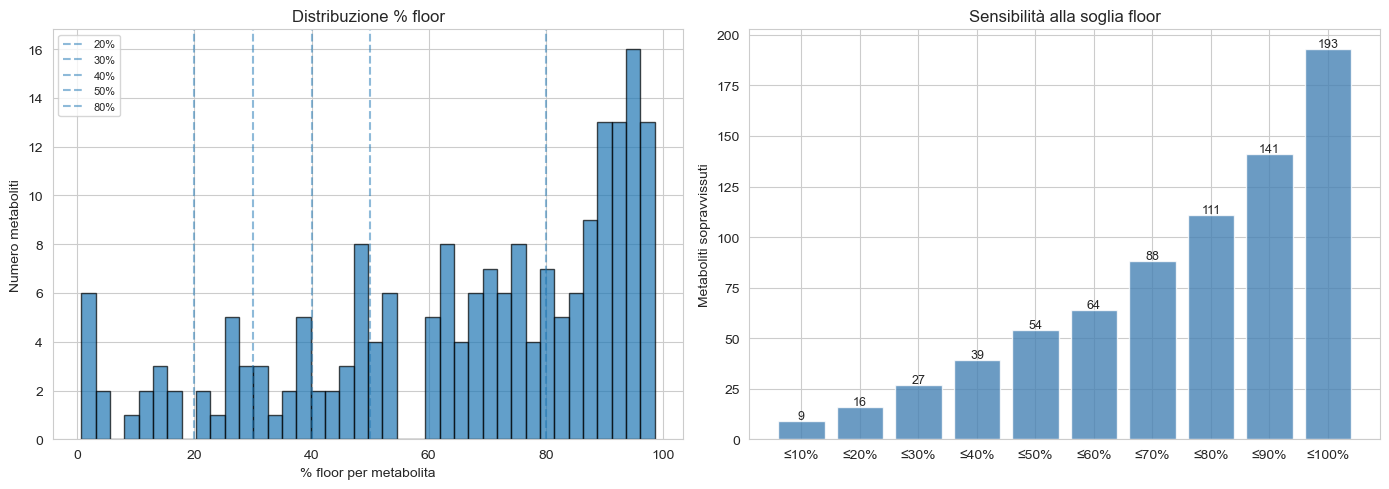

,Soglia,Metaboliti
0,≤10%,9
1,≤20%,16
2,≤30%,27
3,≤40%,39
4,≤50%,54
5,≤60%,64
6,≤70%,88
7,≤80%,111
8,≤90%,141
9,≤100%,193


In [41]:
# ══════════════════════════════════════════════════════════════════════
# MISSINGNESS (pre-filter)
# ══════════════════════════════════════════════════════════════════════
total_vals = df[met_all].size
total_nan  = df[met_all].isna().sum().sum()
print("=" * 60)
print("MISSINGNESS (prima del filtro NaN)")
print("=" * 60)
print(f"Globale: {total_nan}/{total_vals} valori mancanti "
      f"({100 * total_nan / total_vals:.2f}%)")
nan_per_feat = df[met_all].isna().sum().sort_values(ascending=False)
n_feat_nan   = (nan_per_feat > 0).sum()
print(f"Feature con almeno 1 NaN: {n_feat_nan}/{len(met_all)}")
print(f"Feature senza NaN (usate nel master): {len(met_cols)}/{len(met_all)}")

# Per visita
nan_per_visit = df.groupby("Time")[met_all].apply(lambda x: x.isna().sum().sum())
print("\nNaN per visita:")
for t, n in nan_per_visit.items():
    print(f"  T{t} (anno {TIME_TO_YEARS[t]}): {n}")

# ══════════════════════════════════════════════════════════════════════
# FLOOR ANALYSIS (sul master senza NaN)
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("FLOOR ANALYSIS")
print("=" * 60)

floors    = df_master[met_cols].min(axis=0)
is_floor  = df_master[met_cols].eq(floors, axis=1)
pct_floor = (is_floor.mean(axis=0) * 100).sort_values(ascending=False)

print(f"Distribuzione % floor per metabolita:")
print(f"  Media:   {pct_floor.mean():.1f}%")
print(f"  Mediana: {pct_floor.median():.1f}%")
print(f"  Max:     {pct_floor.max():.1f}% ({pct_floor.idxmax()})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Istogramma % floor
axes[0].hist(pct_floor.values, bins=40, edgecolor="black", alpha=0.7)
for thr in [20, 30, 40, 50, 80]:
    axes[0].axvline(thr, ls="--", alpha=0.5, label=f"{thr}%")
axes[0].set_xlabel("% floor per metabolita")
axes[0].set_ylabel("Numero metaboliti")
axes[0].set_title("Distribuzione % floor")
axes[0].legend(fontsize=8)

# Sensibilità alla soglia
thresholds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
surviving  = [int((pct_floor <= t).sum()) for t in thresholds]
axes[1].bar(range(len(thresholds)), surviving,
            tick_label=[f"≤{t}%" for t in thresholds],
            color="steelblue", alpha=0.8)
axes[1].set_ylabel("Metaboliti sopravvissuti")
axes[1].set_title("Sensibilità alla soglia floor")
for i, v in enumerate(surviving):
    axes[1].text(i, v + 1, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# Tabella sensibilità
sens_df = pd.DataFrame({"Soglia": [f"≤{t}%" for t in thresholds],
                         "Metaboliti": surviving})
display(sens_df)

## D. Distribuzioni dei metaboliti

Analisi delle distribuzioni raw e log-trasformate:
- **Skewness** e **kurtosis** (raw vs log₂)
- Presenza di **outlier** (metodo IQR)
- Coefficiente di variazione (CV)
- Confronto visivo raw vs log₂ per metaboliti campione

Skewness (raw):
  Mediana: 9.39
  |skew| > 2: 188/193

Skewness (log2):
  Mediana: 1.20
  |skew| > 2: 75/193


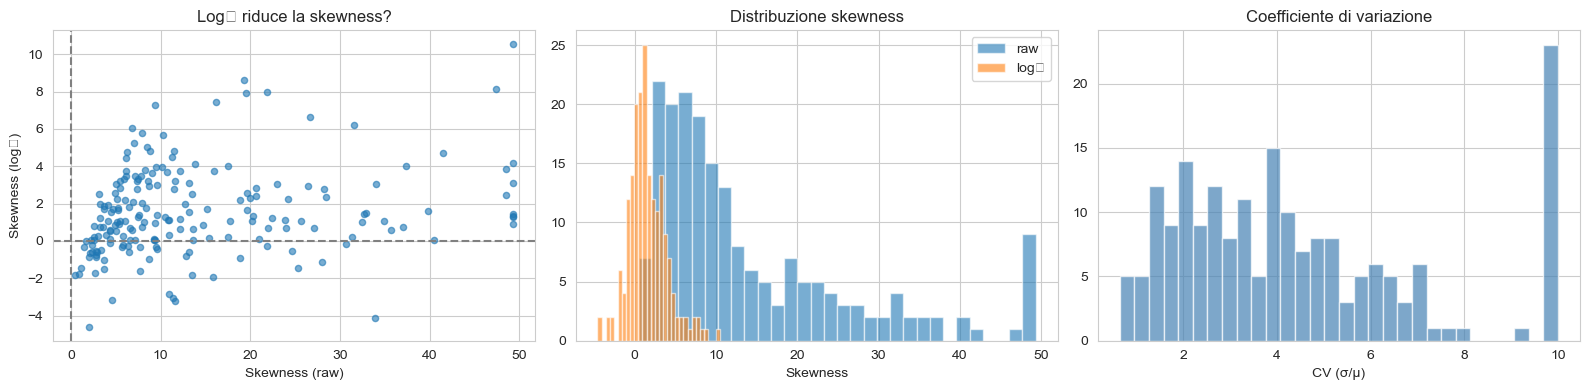


Outlier (IQR): metaboliti con > 5% outlier: 155


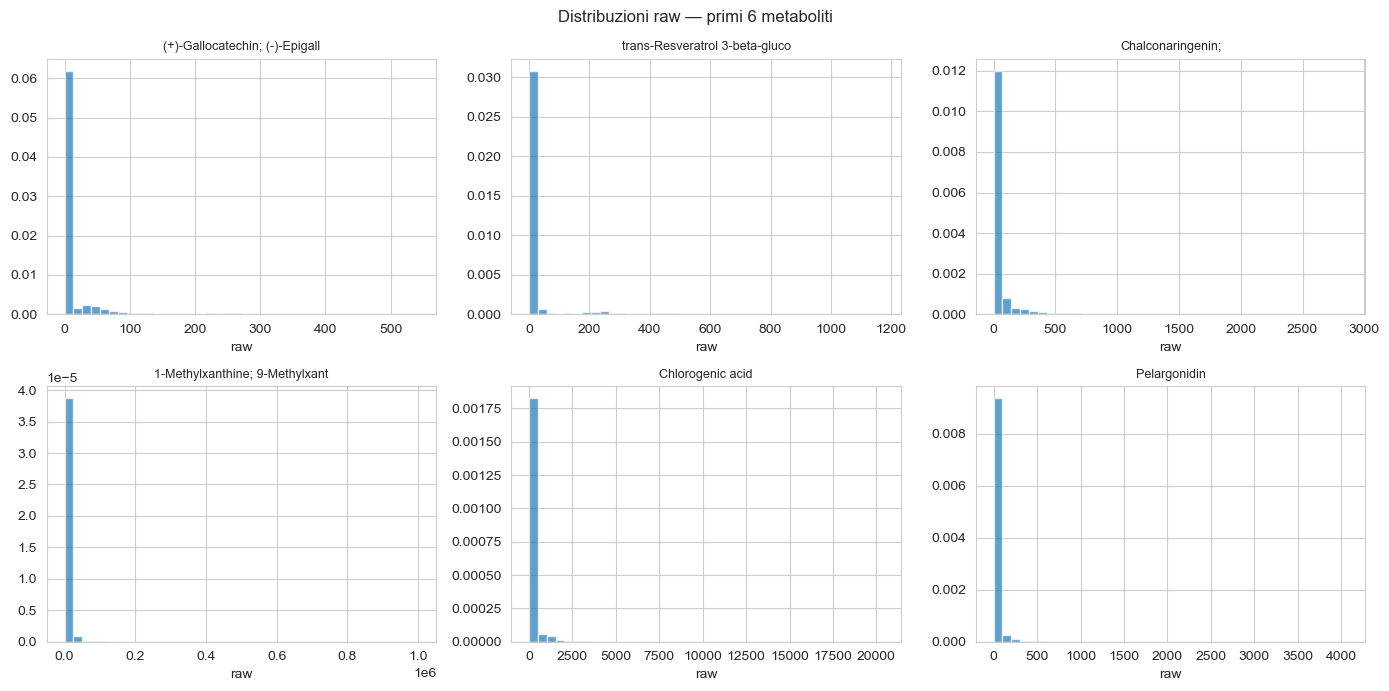

In [42]:
X_raw = df_master[met_cols].astype(float)
X_log = np.log2(X_raw.clip(lower=1e-12))

stats_df = pd.DataFrame({
    "metabolite":    met_cols,
    "mean":          X_raw.mean().values,
    "std":           X_raw.std().values,
    "skew_raw":      X_raw.apply(skew).values,
    "skew_log2":     X_log.apply(skew).values,
    "kurtosis_raw":  X_raw.apply(kurtosis).values,
    "cv":            (X_raw.std() / X_raw.mean().clip(lower=1e-12)).values,
}).sort_values("skew_raw", ascending=False).reset_index(drop=True)

print("Skewness (raw):")
print(f"  Mediana: {stats_df['skew_raw'].median():.2f}")
print(f"  |skew| > 2: {(stats_df['skew_raw'].abs() > 2).sum()}/{len(met_cols)}")
print(f"\nSkewness (log2):")
print(f"  Mediana: {stats_df['skew_log2'].median():.2f}")
print(f"  |skew| > 2: {(stats_df['skew_log2'].abs() > 2).sum()}/{len(met_cols)}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(stats_df["skew_raw"], stats_df["skew_log2"], s=20, alpha=0.6)
axes[0].axhline(0, ls="--", c="gray"); axes[0].axvline(0, ls="--", c="gray")
axes[0].set_xlabel("Skewness (raw)"); axes[0].set_ylabel("Skewness (log₂)")
axes[0].set_title("Log₂ riduce la skewness?")

axes[1].hist(stats_df["skew_raw"], bins=30, alpha=0.6, label="raw")
axes[1].hist(stats_df["skew_log2"], bins=30, alpha=0.6, label="log₂")
axes[1].set_xlabel("Skewness"); axes[1].legend()
axes[1].set_title("Distribuzione skewness")

axes[2].hist(stats_df["cv"].clip(upper=10), bins=30, alpha=0.7, color="steelblue")
axes[2].set_xlabel("CV (σ/μ)"); axes[2].set_title("Coefficiente di variazione")
plt.tight_layout(); plt.show()

# Outlier (IQR)
q1 = X_raw.quantile(0.25); q3 = X_raw.quantile(0.75); iqr = q3 - q1
outlier_mask = (X_raw < (q1 - 1.5 * iqr)) | (X_raw > (q3 + 1.5 * iqr))
pct_outlier = (outlier_mask.sum(axis=0) / len(X_raw) * 100).sort_values(ascending=False)
print(f"\nOutlier (IQR): metaboliti con > 5% outlier: {(pct_outlier > 5).sum()}")

# Esempio: 6 metaboliti (raw vs log2)
example_mets = met_cols[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, m in zip(axes.ravel(), example_mets):
    ax.hist(X_raw[m].dropna(), bins=40, alpha=0.7, density=True)
    ax.set_title(m[:30], fontsize=9)
    ax.set_xlabel("raw")
plt.suptitle("Distribuzioni raw — primi 6 metaboliti", fontsize=12)
plt.tight_layout(); plt.show()

Analizzando 39 metaboliti con floor ≤ 40%
Skewness (raw) — metaboliti floor ≤ 40%:
  Mediana: 6.42
  |skew| > 2: 35/39
Skewness (log2) — metaboliti floor ≤ 40%:
  Mediana: -0.87
  |skew| > 2: 6/39


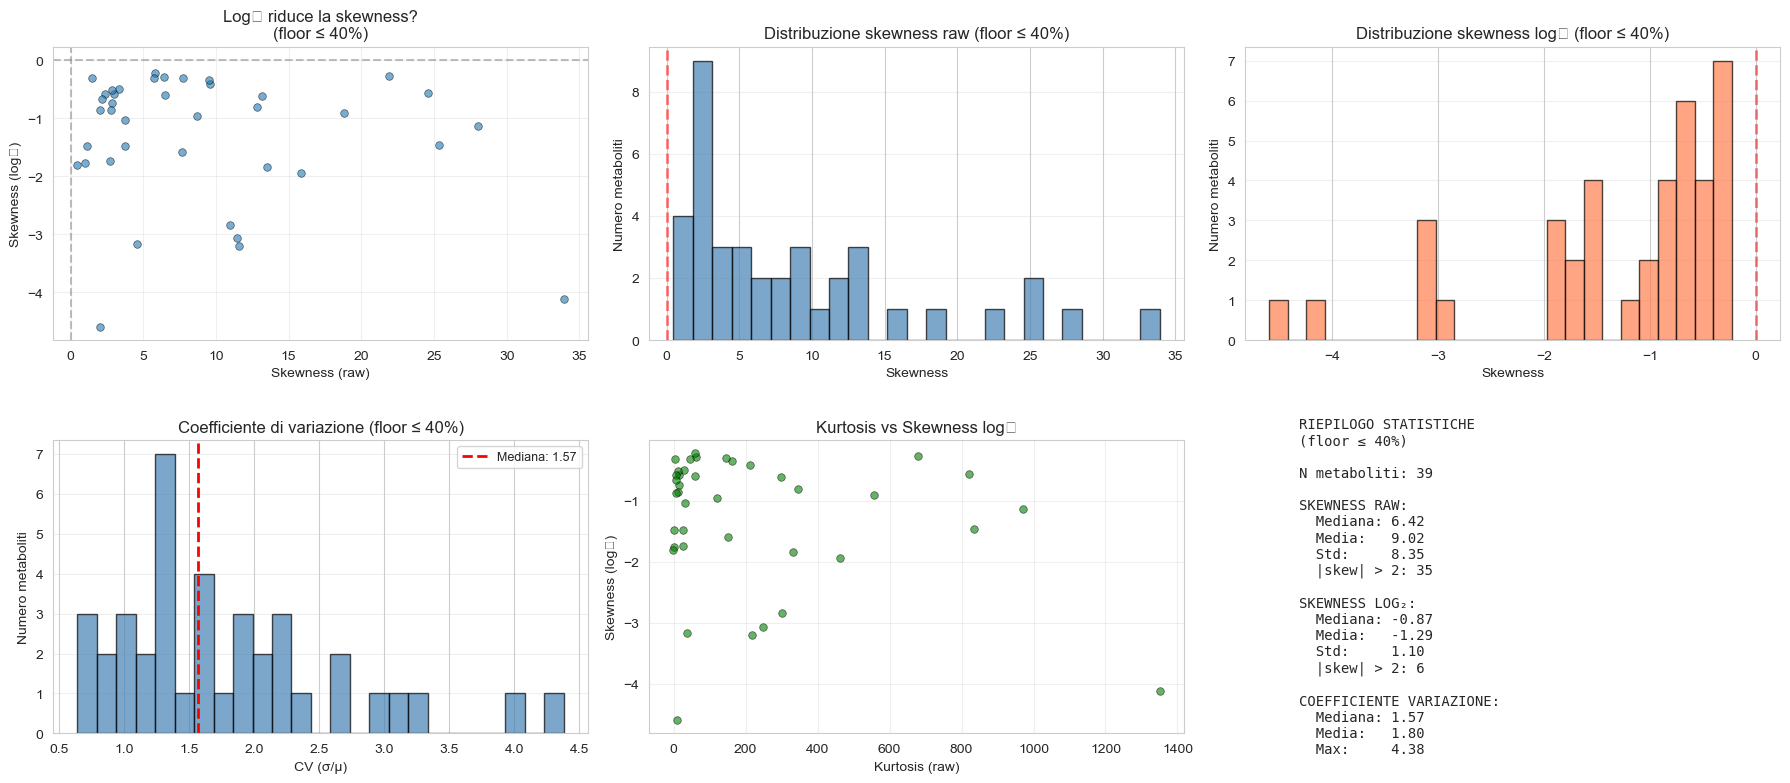


Outlier (IQR) — floor ≤ 40%:
  Metaboliti con > 5% outlier: 25/39
  Metaboliti con > 10% outlier: 9/39
  Top 5 metaboliti con più outlier:
    131646: 20.2%
    Pinoresinol: 19.3%
    Dihomo-gamma-linolenic acid (DGLA; cis-20:3n-6): 13.6%
    Arachidonic acid: 12.6%
    Daidzein: 12.0%


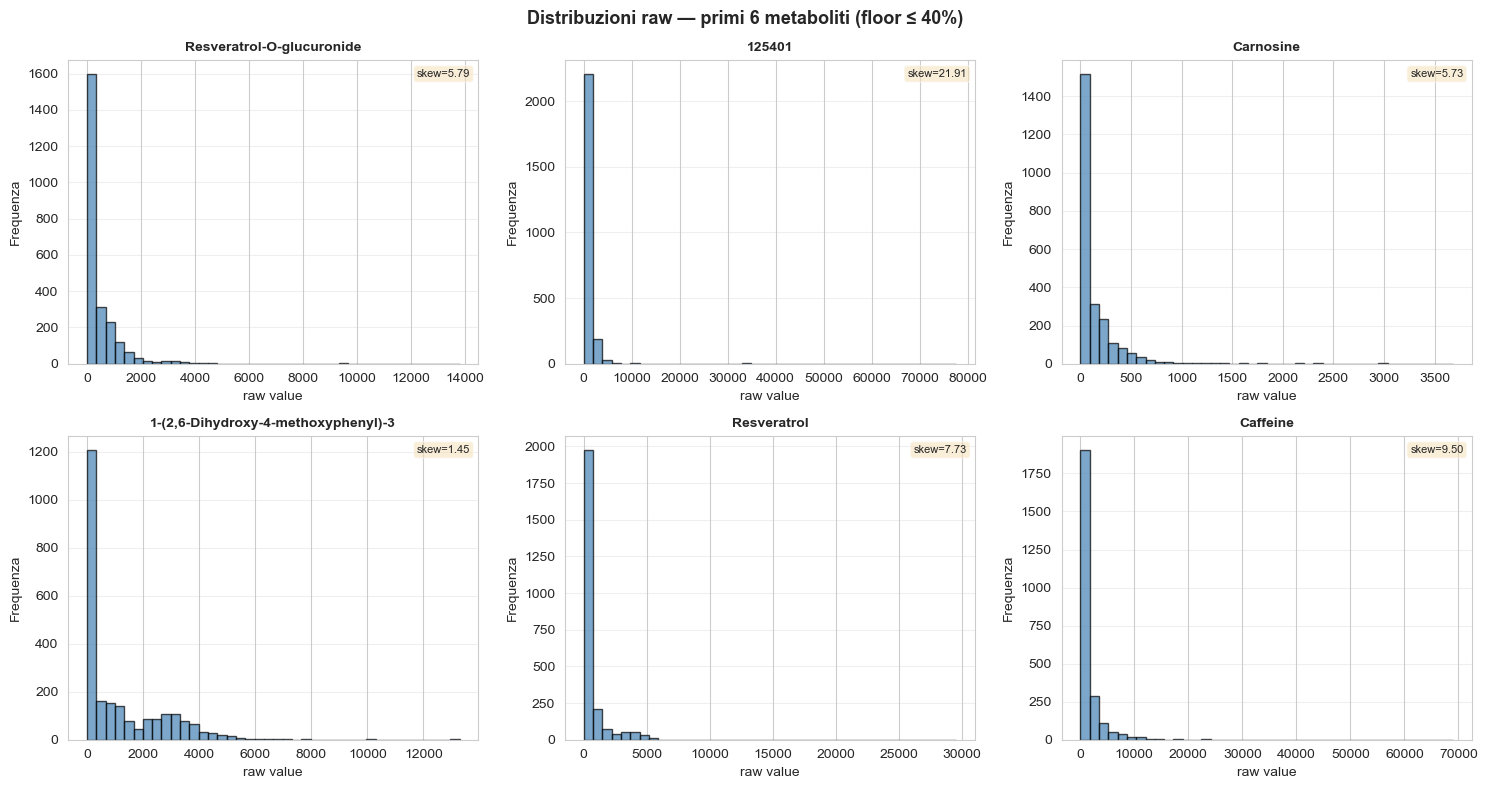

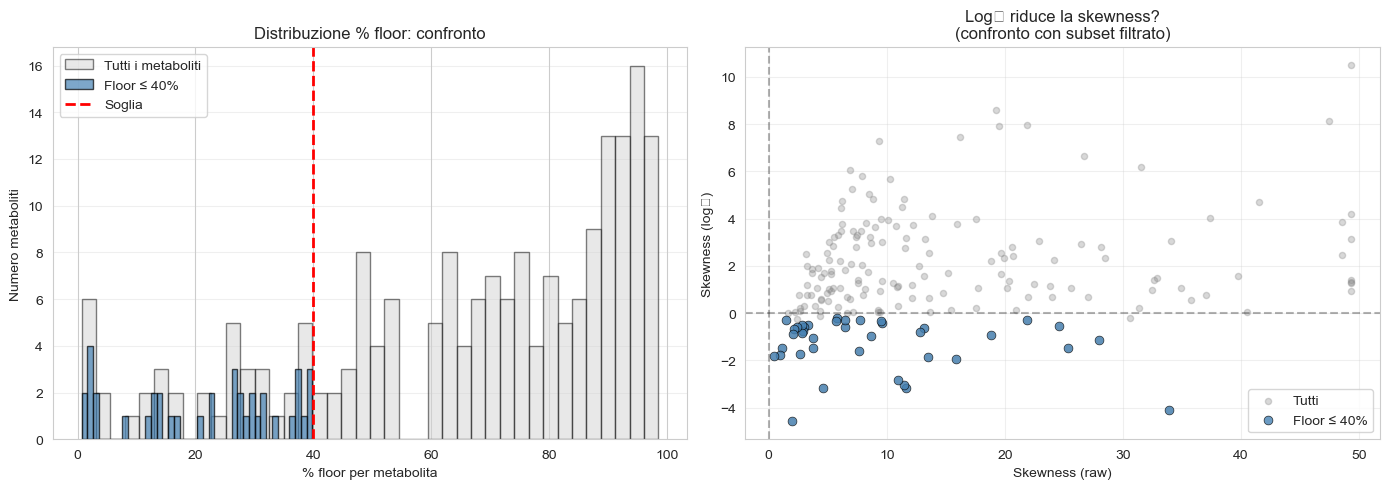


✓ Analisi completata su 39 metaboliti (floor ≤ 40%)
  Miglioramento mediano in skewness: 7.29


In [45]:
# ── D-BIS: DISTRIBUZIONI CON FILTRO FLOOR ────────────────────────────

# ── PARAMETRI FILTRO ──────────────────────────────────────────────────
FLOOR_THR_DIST = 40  # Modifica questo valore per testare soglie diverse

# Seleziona metaboliti che passano la soglia
mets_dist = pct_floor[pct_floor <= FLOOR_THR_DIST].index.tolist()
print(f"Analizzando {len(mets_dist)} metaboliti con floor ≤ {FLOOR_THR_DIST}%")

# ── CALCOLA STATISTICHE SU SUBSET ──────────────────────────────────────
X_raw_filt = df_master[mets_dist].astype(float)
X_log_filt = np.log2(X_raw_filt.clip(lower=1e-12))

stats_df_filt = pd.DataFrame({
    "metabolite":    mets_dist,
    "mean":          X_raw_filt.mean().values,
    "std":           X_raw_filt.std().values,
    "skew_raw":      X_raw_filt.apply(skew).values,
    "skew_log2":     X_log_filt.apply(skew).values,
    "kurtosis_raw":  X_raw_filt.apply(kurtosis).values,
    "cv":            (X_raw_filt.std() / X_raw_filt.mean().clip(lower=1e-12)).values,
}).sort_values("skew_raw", ascending=False).reset_index(drop=True)

print(f"Skewness (raw) — metaboliti floor ≤ {FLOOR_THR_DIST}%:")
print(f"  Mediana: {stats_df_filt['skew_raw'].median():.2f}")
print(f"  |skew| > 2: {(stats_df_filt['skew_raw'].abs() > 2).sum()}/{len(mets_dist)}")
print(f"Skewness (log2) — metaboliti floor ≤ {FLOOR_THR_DIST}%:")
print(f"  Mediana: {stats_df_filt['skew_log2'].median():.2f}")
print(f"  |skew| > 2: {(stats_df_filt['skew_log2'].abs() > 2).sum()}/{len(mets_dist)}")

# ── VISUALIZZAZIONI ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

# Plot 1: Scatter skewness raw vs log2
axes[0, 0].scatter(stats_df_filt["skew_raw"], stats_df_filt["skew_log2"],
                   s=30, alpha=0.6, edgecolor="k", linewidth=0.5)
axes[0, 0].axhline(0, ls="--", c="gray", alpha=0.5)
axes[0, 0].axvline(0, ls="--", c="gray", alpha=0.5)
axes[0, 0].set_xlabel("Skewness (raw)")
axes[0, 0].set_ylabel("Skewness (log₂)")
axes[0, 0].set_title(f"Log₂ riduce la skewness?\n(floor ≤ {FLOOR_THR_DIST}%)")
axes[0, 0].grid(alpha=0.3)

# Plot 2: Istogramma skewness raw
axes[0, 1].hist(stats_df_filt["skew_raw"], bins=25, alpha=0.7,
                color="steelblue", edgecolor="black")
axes[0, 1].axvline(0, ls="--", c="red", alpha=0.5, linewidth=2)
axes[0, 1].set_xlabel("Skewness")
axes[0, 1].set_ylabel("Numero metaboliti")
axes[0, 1].set_title(f"Distribuzione skewness raw (floor ≤ {FLOOR_THR_DIST}%)")
axes[0, 1].grid(alpha=0.3, axis="y")

# Plot 3: Istogramma skewness log2
axes[0, 2].hist(stats_df_filt["skew_log2"], bins=25, alpha=0.7,
                color="coral", edgecolor="black")
axes[0, 2].axvline(0, ls="--", c="red", alpha=0.5, linewidth=2)
axes[0, 2].set_xlabel("Skewness")
axes[0, 2].set_ylabel("Numero metaboliti")
axes[0, 2].set_title(f"Distribuzione skewness log₂ (floor ≤ {FLOOR_THR_DIST}%)")
axes[0, 2].grid(alpha=0.3, axis="y")

# Plot 4: Coefficiente di variazione
cv_clipped = stats_df_filt["cv"].clip(upper=10)
axes[1, 0].hist(cv_clipped, bins=25, alpha=0.7,
                color="steelblue", edgecolor="black")
axes[1, 0].axvline(cv_clipped.median(), ls="--", c="red", linewidth=2,
                   label=f"Mediana: {cv_clipped.median():.2f}")
axes[1, 0].set_xlabel("CV (σ/μ)")
axes[1, 0].set_ylabel("Numero metaboliti")
axes[1, 0].set_title(f"Coefficiente di variazione (floor ≤ {FLOOR_THR_DIST}%)")
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(alpha=0.3, axis="y")

# Plot 5: Kurtosis raw vs log2
axes[1, 1].scatter(stats_df_filt["kurtosis_raw"], stats_df_filt["skew_log2"],
                   s=30, alpha=0.6, edgecolor="k", linewidth=0.5, c="green")
axes[1, 1].set_xlabel("Kurtosis (raw)")
axes[1, 1].set_ylabel("Skewness (log₂)")
axes[1, 1].set_title(f"Kurtosis vs Skewness log₂")
axes[1, 1].grid(alpha=0.3)

# Plot 6: Tabella riassuntiva (come grafico di testo)
axes[1, 2].axis("off")
summary_text = f"""
RIEPILOGO STATISTICHE
(floor ≤ {FLOOR_THR_DIST}%)

N metaboliti: {len(mets_dist)}

SKEWNESS RAW:
  Mediana: {stats_df_filt['skew_raw'].median():.2f}
  Media:   {stats_df_filt['skew_raw'].mean():.2f}
  Std:     {stats_df_filt['skew_raw'].std():.2f}
  |skew| > 2: {(stats_df_filt['skew_raw'].abs() > 2).sum()}

SKEWNESS LOG₂:
  Mediana: {stats_df_filt['skew_log2'].median():.2f}
  Media:   {stats_df_filt['skew_log2'].mean():.2f}
  Std:     {stats_df_filt['skew_log2'].std():.2f}
  |skew| > 2: {(stats_df_filt['skew_log2'].abs() > 2).sum()}

COEFFICIENTE VARIAZIONE:
  Mediana: {cv_clipped.median():.2f}
  Media:   {cv_clipped.mean():.2f}
  Max:     {cv_clipped.max():.2f}
"""
axes[1, 2].text(0.1, 0.5, summary_text, fontsize=10, family="monospace",
                verticalalignment="center", transform=axes[1, 2].transAxes)

plt.tight_layout()
plt.show()

# ── OUTLIER (IQR) SU SUBSET ───────────────────────────────────────────
q1_f = X_raw_filt.quantile(0.25)
q3_f = X_raw_filt.quantile(0.75)
iqr_f = q3_f - q1_f
outlier_mask_f = (X_raw_filt < (q1_f - 1.5 * iqr_f)) | (X_raw_filt > (q3_f + 1.5 * iqr_f))
pct_outlier_f = (outlier_mask_f.sum(axis=0) / len(X_raw_filt) * 100).sort_values(ascending=False)

print(f"\nOutlier (IQR) — floor ≤ {FLOOR_THR_DIST}%:")
print(f"  Metaboliti con > 5% outlier: {(pct_outlier_f > 5).sum()}/{len(mets_dist)}")
print(f"  Metaboliti con > 10% outlier: {(pct_outlier_f > 10).sum()}/{len(mets_dist)}")
if (pct_outlier_f > 5).sum() > 0:
    print(f"  Top 5 metaboliti con più outlier:")
    for m, pct in pct_outlier_f.head(5).items():
        print(f"    {m}: {pct:.1f}%")

# ── ESEMPIO: 6 METABOLITI (raw vs log2) ────────────────────────────────
n_example = min(6, len(mets_dist))
example_mets_filt = mets_dist[:n_example]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, m in enumerate(example_mets_filt):
    axes[i].hist(X_raw_filt[m].dropna(), bins=40, alpha=0.7,
                 color="steelblue", edgecolor="black")
    axes[i].set_title(m[:35], fontsize=10, fontweight="bold")
    axes[i].set_xlabel("raw value")
    axes[i].set_ylabel("Frequenza")
    axes[i].grid(alpha=0.3, axis="y")
    
    # Aggiungi statistiche
    skew_val = stats_df_filt.loc[stats_df_filt["metabolite"] == m, "skew_raw"].values[0]
    axes[i].text(0.98, 0.97, f"skew={skew_val:.2f}",
                 transform=axes[i].transAxes, fontsize=8,
                 verticalalignment="top", horizontalalignment="right",
                 bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

for j in range(n_example, 6):
    axes[j].set_visible(False)

plt.suptitle(f"Distribuzioni raw — primi {n_example} metaboliti (floor ≤ {FLOOR_THR_DIST}%)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── CONFRONTO: tutti metaboliti vs subset floor-filtrato ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuzione % floor
axes[0].hist(pct_floor.values, bins=40, alpha=0.5, label="Tutti i metaboliti",
             color="lightgray", edgecolor="black")
axes[0].hist(stats_df_filt["metabolite"].apply(lambda m: pct_floor[m]).values,
             bins=40, alpha=0.7, label=f"Floor ≤ {FLOOR_THR_DIST}%",
             color="steelblue", edgecolor="black")
axes[0].axvline(FLOOR_THR_DIST, ls="--", c="red", linewidth=2, label="Soglia")
axes[0].set_xlabel("% floor per metabolita")
axes[0].set_ylabel("Numero metaboliti")
axes[0].set_title("Distribuzione % floor: confronto")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")

# Skewness: raw vs log2
axes[1].scatter(stats_df["skew_raw"], stats_df["skew_log2"], s=20, alpha=0.3,
                label="Tutti", color="gray")
subset_mask = stats_df["metabolite"].isin(mets_dist)
axes[1].scatter(stats_df.loc[subset_mask, "skew_raw"],
                stats_df.loc[subset_mask, "skew_log2"],
                s=40, alpha=0.8, edgecolor="k", linewidth=0.5,
                label=f"Floor ≤ {FLOOR_THR_DIST}%", color="steelblue")
axes[1].axhline(0, ls="--", c="black", alpha=0.3)
axes[1].axvline(0, ls="--", c="black", alpha=0.3)
axes[1].set_xlabel("Skewness (raw)")
axes[1].set_ylabel("Skewness (log₂)")
axes[1].set_title("Log₂ riduce la skewness?\n(confronto con subset filtrato)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Analisi completata su {len(mets_dist)} metaboliti (floor ≤ {FLOOR_THR_DIST}%)")
print(f"  Miglioramento mediano in skewness: {(stats_df_filt['skew_raw'].median() - stats_df_filt['skew_log2'].median()):.2f}")

## E. Definizione gruppi di fragilità

**Definizione:** Frail = **FI ≥ 0.25**

Gruppi costruiti:
- **Per visita:** frail / not-frail a ogni timepoint
- **Ever-frail:** FI ≥ 0.25 in almeno una visita
- **Never-frail:** FI < 0.25 in tutte le visite
- **Stato a T4:** frail / not-frail all'ultimo timepoint

La definizione **Ever-frail** è quella usata in TCAM.

Frailty per visita:


,n_frail,n_total,n_not_frail,pct_frail
T1 (anno 0),0,609,609,0.0
T2 (anno 2),24,609,585,3.9
T3 (anno 4),35,609,574,5.7
T4 (anno 8),147,609,462,24.1



Ever-frail: 152,  Never-frail: 457
Frail a T4: 147, Not-frail a T4: 462

Overlap tra definizioni:


,Gruppo,N
0,Ever-frail,152
1,Frail a T4,147
2,In comune,147
3,Solo ever-frail,5
4,Solo frail a T4,0


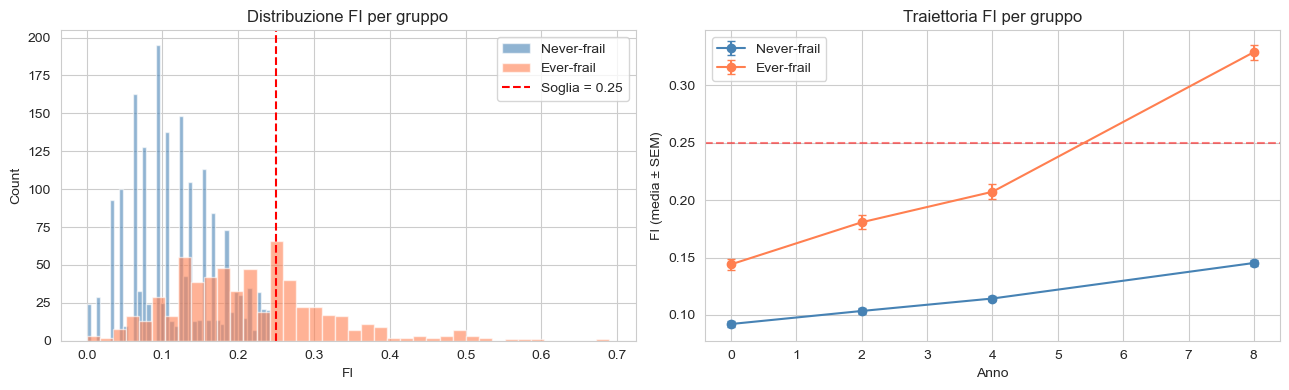

In [23]:
# ── FRAILTY PER VISITA ────────────────────────────────────────────────
df_master["Frail"] = (df_master["FI"] >= FRAIL_THR).astype(int)
frail_per_visit = df_master.groupby("Time")["Frail"].agg(["sum", "count"])
frail_per_visit.columns = ["n_frail", "n_total"]
frail_per_visit["n_not_frail"] = frail_per_visit["n_total"] - frail_per_visit["n_frail"]
frail_per_visit["pct_frail"]   = (frail_per_visit["n_frail"] / frail_per_visit["n_total"] * 100).round(1)
frail_per_visit.index = [f"T{t} (anno {TIME_TO_YEARS[t]})" for t in frail_per_visit.index]
print("Frailty per visita:")
display(frail_per_visit)

# ── EVER / NEVER FRAIL ───────────────────────────────────────────────
ever_frail_map = (
    df_master.groupby("Code")["FI"].max() >= FRAIL_THR
).map({True: "Ever-frail", False: "Never-frail"})
df_master["Group"] = df_master["Code"].map(ever_frail_map)
df_master["Group"] = pd.Categorical(df_master["Group"],
                                     categories=["Never-frail", "Ever-frail"])
n_ef = (ever_frail_map == "Ever-frail").sum()
n_nf = (ever_frail_map == "Never-frail").sum()
print(f"\nEver-frail: {n_ef},  Never-frail: {n_nf}")

# ── STATO A T4 ───────────────────────────────────────────────────────
t4 = df_master.loc[df_master["Time"] == 4, ["Code", "FI"]].copy()
t4["frail_T4"] = t4["FI"] >= FRAIL_THR
n_frail_t4 = t4["frail_T4"].sum()
print(f"Frail a T4: {n_frail_t4}, Not-frail a T4: {len(t4) - n_frail_t4}")

# ── OVERLAP ──────────────────────────────────────────────────────────
ever_ids = set(ever_frail_map[ever_frail_map == "Ever-frail"].index)
t4_ids   = set(t4.loc[t4["frail_T4"], "Code"])
overlap = pd.DataFrame({
    "Gruppo": ["Ever-frail", "Frail a T4", "In comune",
               "Solo ever-frail", "Solo frail a T4"],
    "N": [len(ever_ids), len(t4_ids), len(ever_ids & t4_ids),
          len(ever_ids - t4_ids), len(t4_ids - ever_ids)]
})
print("\nOverlap tra definizioni:")
display(overlap)

# ── PLOT: distribuzione FI + traiettorie ─────────────────────────────
colors = {"Never-frail": "steelblue", "Ever-frail": "coral"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for grp in ["Never-frail", "Ever-frail"]:
    sub = df_master[df_master["Group"] == grp]
    axes[0].hist(sub["FI"], bins=40, alpha=0.6, label=grp, color=colors[grp])
axes[0].axvline(FRAIL_THR, ls="--", c="red", label=f"Soglia = {FRAIL_THR}")
axes[0].set_xlabel("FI"); axes[0].set_ylabel("Count")
axes[0].set_title("Distribuzione FI per gruppo"); axes[0].legend()

fi_mean = df_master.groupby(["Years", "Group"])["FI"].agg(["mean", "sem"]).reset_index()
for grp in ["Never-frail", "Ever-frail"]:
    sub = fi_mean[fi_mean["Group"] == grp]
    axes[1].errorbar(sub["Years"], sub["mean"], yerr=sub["sem"],
                     marker="o", label=grp, color=colors[grp], capsize=3)
axes[1].axhline(FRAIL_THR, ls="--", c="red", alpha=0.5)
axes[1].set_xlabel("Anno"); axes[1].set_ylabel("FI (media ± SEM)")
axes[1].set_title("Traiettoria FI per gruppo"); axes[1].legend()
plt.tight_layout(); plt.show()

## F. Sankey — Transizioni di fragilità tra visite

Diagramma Sankey che mostra come i pazienti transitano tra stato frail (FI ≥ 0.25)
e not-frail tra ogni coppia di visite consecutive.

In [24]:
def build_sankey(df_src, frail_thr, title="Transizioni fragilità"):
    """Build a Sankey diagram of frailty transitions across visits."""
    pivot = df_src.pivot(index="Code", columns="Time", values="FI")
    status = (pivot >= frail_thr).astype(int)  # 1=frail, 0=not-frail

    labels, sources, targets, values, link_colors = [], [], [], [], []
    time_list = sorted(status.columns)

    # Nodi: 2 per visita (not-frail, frail)
    for i, t in enumerate(time_list):
        n_nf = (status[t] == 0).sum()
        n_fr = (status[t] == 1).sum()
        labels.append(f"T{t} NF ({n_nf})")
        labels.append(f"T{t} F ({n_fr})")

    # Link: transizioni tra visite consecutive
    colors_map = {"NF→NF": "rgba(70,130,180,0.4)",
                  "NF→F":  "rgba(255,127,80,0.5)",
                  "F→NF":  "rgba(144,238,144,0.5)",
                  "F→F":   "rgba(220,20,60,0.4)"}
    for i in range(len(time_list) - 1):
        t_from, t_to = time_list[i], time_list[i + 1]
        for s_from in [0, 1]:
            for s_to in [0, 1]:
                cnt = int(((status[t_from] == s_from) & (status[t_to] == s_to)).sum())
                if cnt == 0:
                    continue
                src_idx = i * 2 + s_from
                tgt_idx = (i + 1) * 2 + s_to
                sources.append(src_idx)
                targets.append(tgt_idx)
                values.append(cnt)
                lbl = ("F" if s_from else "NF") + "→" + ("F" if s_to else "NF")
                link_colors.append(colors_map[lbl])

    fig = go.Figure(go.Sankey(
        node=dict(pad=15, thickness=20, label=labels,
                  color=["steelblue" if "NF" in l else "coral" for l in labels]),
        link=dict(source=sources, target=targets, value=values, color=link_colors)))
    fig.update_layout(title_text=title, font_size=12,
                      width=800, height=400)
    fig.show()

    # Tabella transizioni
    trans_rows = []
    for i in range(len(time_list) - 1):
        t_from, t_to = time_list[i], time_list[i + 1]
        for s_from in [0, 1]:
            for s_to in [0, 1]:
                cnt = int(((status[t_from] == s_from) & (status[t_to] == s_to)).sum())
                trans_rows.append({
                    "Da": f"T{t_from}", "A": f"T{t_to}",
                    "Stato_da": "Frail" if s_from else "Not-frail",
                    "Stato_a":  "Frail" if s_to   else "Not-frail",
                    "N": cnt
                })
    display(pd.DataFrame(trans_rows))

# ── SANKEY COMPLETO ──────────────────────────────────────────────────
build_sankey(df_master, FRAIL_THR, title="Transizioni fragilità (FI ≥ 0.25)")

,Da,A,Stato_da,Stato_a,N
0,T1,T2,Not-frail,Not-frail,585
1,T1,T2,Not-frail,Frail,24
2,T1,T2,Frail,Not-frail,0
3,T1,T2,Frail,Frail,0
4,T2,T3,Not-frail,Not-frail,566
5,T2,T3,Not-frail,Frail,19
6,T2,T3,Frail,Not-frail,8
7,T2,T3,Frail,Frail,16
8,T3,T4,Not-frail,Not-frail,458
9,T3,T4,Not-frail,Frail,116


## G. Analisi longitudinale

- **Medie globali** per metabolita nel tempo
- **Traiettorie per gruppo** (Ever-frail vs Never-frail)
- **Eterogeneità** intra-gruppo (bande di confidenza)
- **Heatmap** variazioni medie per visita

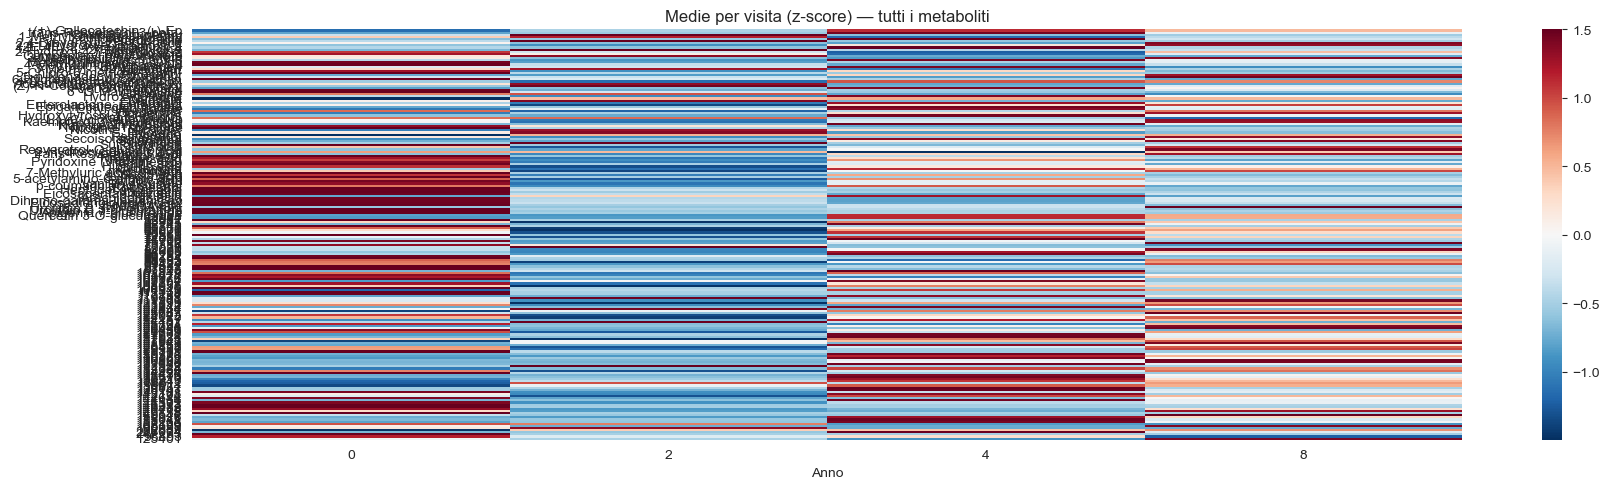

Metaboliti con floor ≤ 40%: 39/193


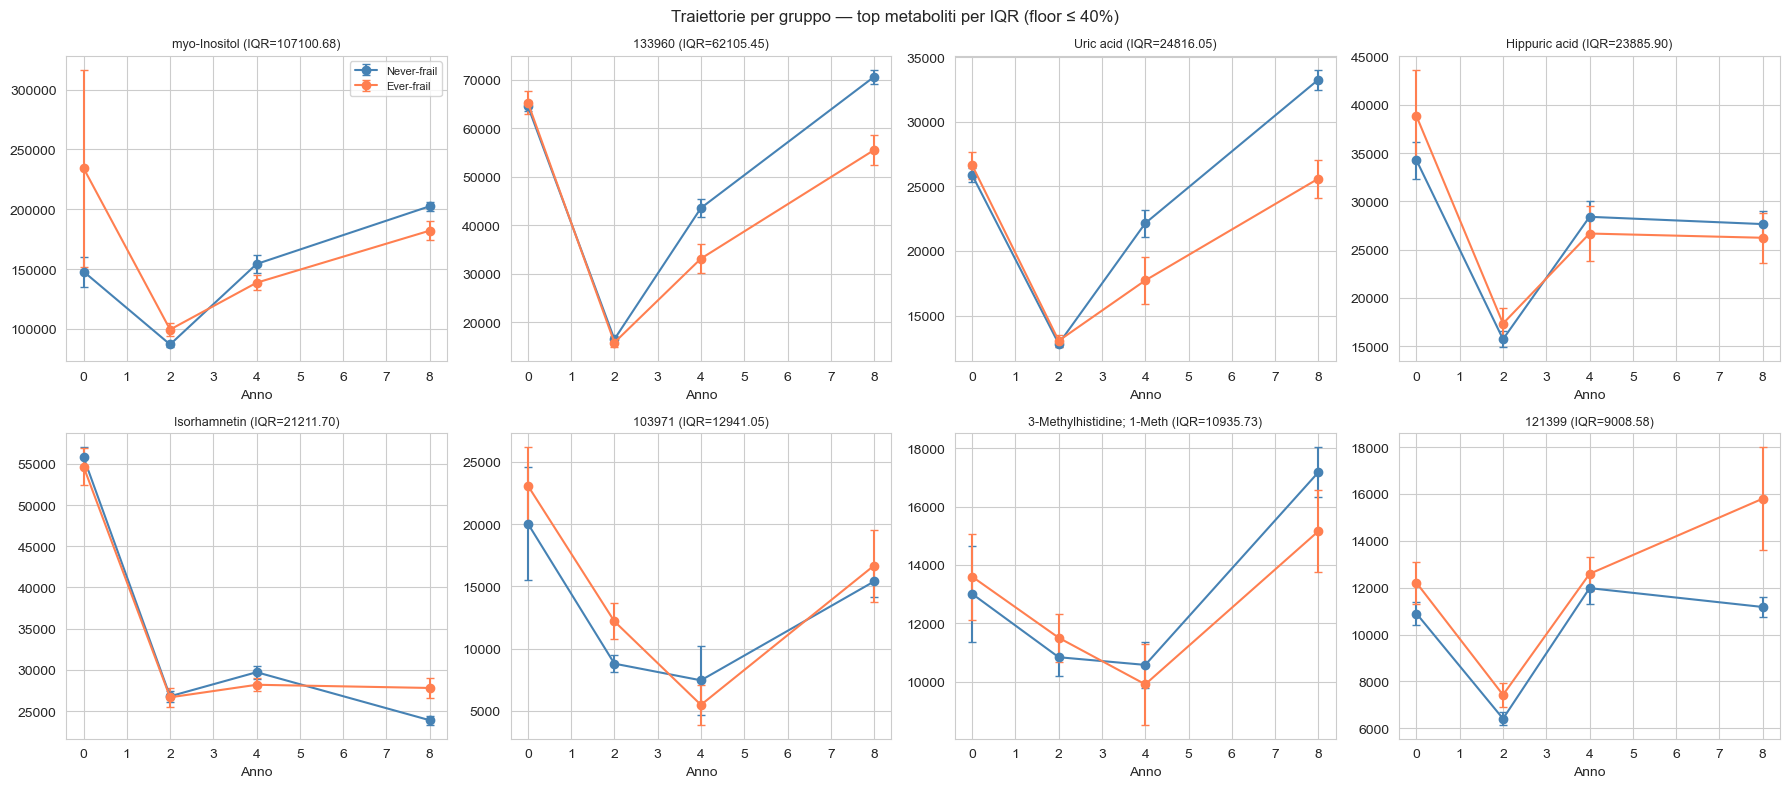


ICC proxy su metaboliti floor ≤ 40%:
  Mediana: 0.201
  Mean:    0.209
  < 0.3 (alta eterogeneità intra): 36/39


In [36]:
# ── MEDIE GLOBALI PER VISITA ──────────────────────────────────────────
means_by_visit = df_master.groupby("Years")[met_cols].mean()
z_means = (means_by_visit - means_by_visit.mean()) / means_by_visit.std().clip(lower=1e-12)

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(z_means.T, cmap="RdBu_r", center=0, ax=ax,
            yticklabels=[m[:25] for m in met_cols])
ax.set_title("Medie per visita (z-score) — tutti i metaboliti")
ax.set_xlabel("Anno"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

# ── PARAMETRI ──────────────────────────────────────────────────────────
FLOOR_THR_ICC = 40  # soglia floor (%) per ICC e ranking robusto

# metaboliti che passano la soglia floor (pct_floor è calcolato in sezione C)
mets_floor_ok = pct_floor[pct_floor <= FLOOR_THR_ICC].index.tolist()
print(f"Metaboliti con floor ≤ {FLOOR_THR_ICC}%: {len(mets_floor_ok)}/{len(met_cols)}")

# ── TOP 8 PER IQR (robusto) ────────────────────────────────────────────
X_sel = df_master[mets_floor_ok].astype(float)
iqr_per_met = X_sel.quantile(0.75) - X_sel.quantile(0.25)
top_iqr = iqr_per_met.nlargest(min(8, len(iqr_per_met))).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = np.atleast_1d(axes).ravel()

for ax, m in zip(axes, top_iqr):
    for grp in ["Never-frail", "Ever-frail"]:
        sub = df_master[df_master["Group"] == grp]
        gm = sub.groupby("Years")[m].agg(["mean", "sem"])
        ax.errorbar(gm.index, gm["mean"], yerr=gm["sem"],
                    marker="o", label=grp, color=colors[grp], capsize=3)
    ax.set_title(f"{m[:25]} (IQR={iqr_per_met[m]:.2f})", fontsize=9)
    ax.set_xlabel("Anno")

for j in range(len(top_iqr), len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=8)
plt.suptitle(f"Traiettorie per gruppo — top metaboliti per IQR (floor ≤ {FLOOR_THR_ICC}%)", fontsize=12)
plt.tight_layout(); plt.show()

# ── ICC PROXY SOLO SU METABOLITI CON SOGLIA FLOOR ──────────────────────
if len(mets_floor_ok) > 0:
    intra_var = df_master.groupby("Code")[mets_floor_ok].var().mean()
    inter_var = df_master.groupby("Code")[mets_floor_ok].mean().var()
    icc_proxy = inter_var / (inter_var + intra_var).clip(lower=1e-12)

    print(f"\nICC proxy su metaboliti floor ≤ {FLOOR_THR_ICC}%:")
    print(f"  Mediana: {icc_proxy.median():.3f}")
    print(f"  Mean:    {icc_proxy.mean():.3f}")
    print(f"  < 0.3 (alta eterogeneità intra): {(icc_proxy < 0.3).sum()}/{len(icc_proxy)}")
else:
    print(f"\nNessun metabolita con floor ≤ {FLOOR_THR_ICC}%: ICC non calcolabile.")

## H. Drift / visit effect

Verifica se le medie globali cambiano sistematicamente tra le visite
(potenziale effetto batch / drift strumentale).

- **Drift globale:** media di tutti i metaboliti per visita
- **Drift per metabolita:** ANOVA one-way (visite come gruppi)
- Questo guida la scelta delle normalizzazioni in TCAM

Drift globale (media di tutti i metaboliti per visita):
  Anno 0: media = 8819.86, mediana = 0.82, P75 = 3252.29, media no-floor = 29360.70
  Anno 2: media = 1427.41, mediana = 0.34, P75 = 1558.21, media no-floor = 2458.97
  Anno 4: media = 2614.02, mediana = 0.34, P75 = 3412.52, media no-floor = 4830.40
  Anno 8: media = 2798.22, mediana = 0.72, P75 = 3414.09, media no-floor = 4164.83


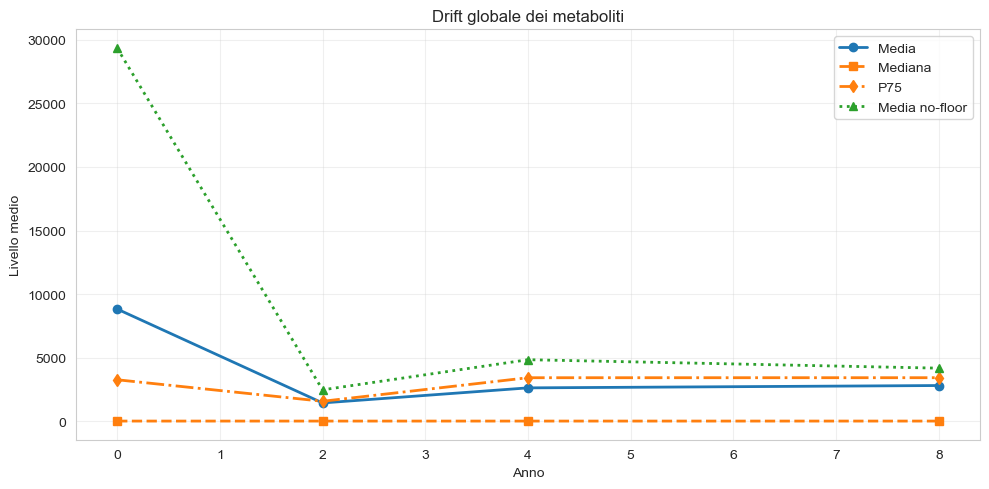


Metaboliti con drift significativo (ANOVA, FDR < 0.05): 175/193


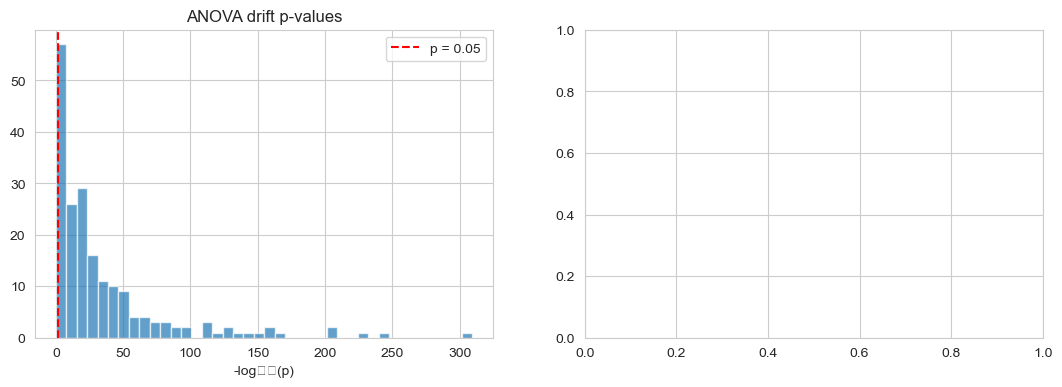

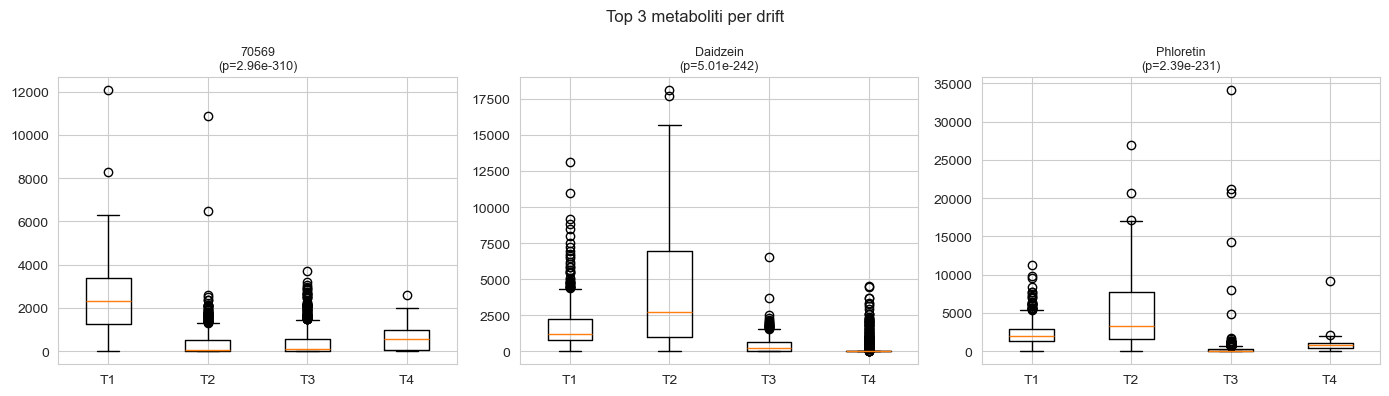


Top 10 metaboliti per drift:


,met,p,q
0,70569,2.955057e-310,5.703260e-308
1,Daidzein,5.014993e-242,4.839468e-240
2,Phloretin,2.386014e-231,1.535002e-229
3,133960,4.773742e-208,2.303331e-206
4,Isorhamnetin,1.027816e-205,3.967371e-204
5,136851,1.421887e-164,4.573736e-163
6,Apigenin 7-glucuronide,1.171451e-161,3.229857e-160
7,131646,2.757570e-160,6.652637e-159
8,129151,1.277119e-152,2.738712e-151
9,144134,6.499109e-147,1.254328e-145


In [52]:
# ── DRIFT GLOBALE ─────────────────────────────────────────────────────
global_mean = df_master.groupby("Years")[met_cols].mean().mean(axis=1)
global_median = df_master.groupby("Years")[met_cols].median().median(axis=1)
global_p75 = df_master.groupby("Years")[met_cols].quantile(0.75).mean(axis=1)

# Media no-floor: escludi valori al floor prima di calcolare la media
floors_global = df_master[met_cols].min(axis=0)
is_floor_global = df_master[met_cols].eq(floors_global, axis=1)
X_nofloor = df_master[met_cols].mask(is_floor_global)
global_mean_nofloor = X_nofloor.groupby(df_master["Years"]).mean().mean(axis=1)

print("Drift globale (media di tutti i metaboliti per visita):")
for y in sorted(global_mean.index):
    print(f"  Anno {y}: media = {global_mean[y]:.2f}, mediana = {global_median[y]:.2f}, "
          f"P75 = {global_p75[y]:.2f}, media no-floor = {global_mean_nofloor[y]:.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(global_mean.index, global_mean.values, "o-", label="Media", linewidth=2)
ax.plot(global_median.index, global_median.values, "s--", label="Mediana", linewidth=2)
ax.plot(global_p75.index, global_p75.values, "d-.", label="P75", linewidth=2, color="tab:orange")
ax.plot(global_mean_nofloor.index, global_mean_nofloor.values, "^:", label="Media no-floor", 
        linewidth=2, color="tab:green")
ax.set_xlabel("Anno")
ax.set_ylabel("Livello medio")
ax.set_title("Drift globale dei metaboliti")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── ANOVA PER METABOLITA (visita come fattore) ────────────────────────
drift_pvals = []
for m in met_cols:
    groups = [df_master.loc[df_master["Time"] == t, m].dropna().values for t in TIMES]
    if all(len(g) > 2 for g in groups):
        _, p = f_oneway(*groups)
        drift_pvals.append(p)
    else:
        drift_pvals.append(np.nan)

drift_pvals = np.array(drift_pvals)
drift_qvals = fdr_bh(drift_pvals)
n_sig_drift = np.nansum(drift_qvals < 0.05)
print(f"\nMetaboliti con drift significativo (ANOVA, FDR < 0.05): "
      f"{n_sig_drift}/{len(met_cols)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(-np.log10(drift_pvals[np.isfinite(drift_pvals)]), bins=40, alpha=0.7)
axes[0].axvline(-np.log10(0.05), ls="--", c="red", label="p = 0.05")
axes[0].set_xlabel("-log₁₀(p)")
axes[0].set_title("ANOVA drift p-values")
axes[0].legend()

# Top 6 metaboliti con drift
drift_df = pd.DataFrame({"met": met_cols, "p": drift_pvals, "q": drift_qvals})
drift_df = drift_df.sort_values("p").reset_index(drop=True)
top_drift = drift_df.head(6)["met"].tolist()

# Boxplot dei top 3
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
for ax, m in zip(axes2.ravel(), top_drift[:3]):
    data_box = [df_master.loc[df_master["Time"] == t, m].values for t in TIMES]
    ax.boxplot(data_box, labels=[f"T{t}" for t in TIMES])
    ax.set_title(f"{m[:25]}\n(p={drift_df.loc[drift_df.met==m, 'p'].values[0]:.2e})",
                 fontsize=9)
plt.suptitle("Top 3 metaboliti per drift", fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 10 metaboliti per drift:")
display(drift_df.head(10))

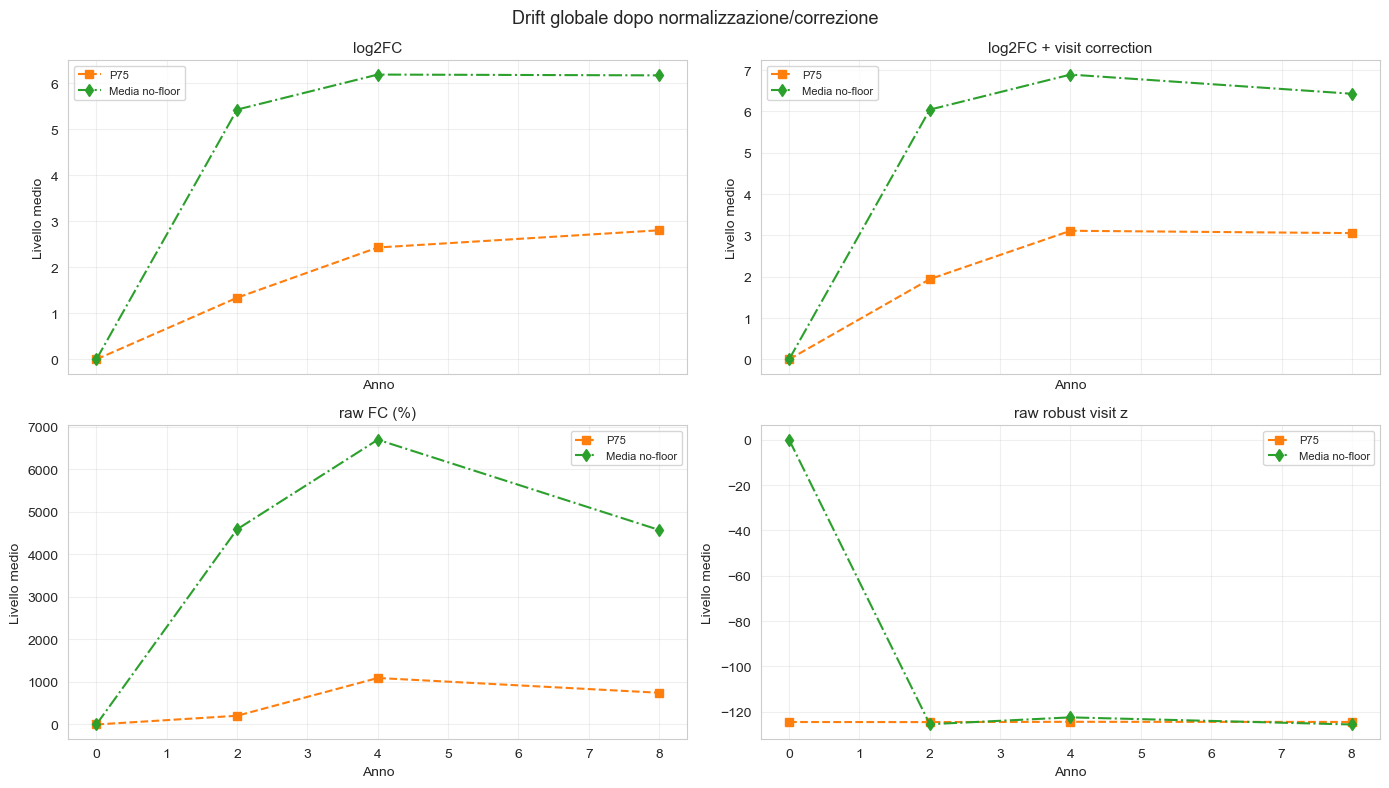

,Metodo,Range P75 (max-min),Range media no-floor (max-min)
3,raw robust visit z,0.127439,125.653115
0,log2FC,2.804065,6.187535
1,log2FC + visit correction,3.110668,6.889735
2,raw FC (%),1092.630560,6690.225762


In [51]:
# ── H-BIS. Confronto metodi anti-visit effect sul drift globale ──────────────

# Dati base (raw)
X_raw_vals = df_master[met_cols].astype(float).clip(lower=1e-12)
years = df_master["Years"]
times = df_master["Time"]

# floor mask dal raw (valida per tutti i metodi)
floors_ref = X_raw_vals.min(axis=0)
floor_mask = X_raw_vals.eq(floors_ref, axis=1)

def _anchor_to_year0(Xmat, years, floor_mask=None, mode="mean_nofloor"):
    """
    Ancora ogni metabolita a Year=0 sottraendo un riferimento per-colonna.
    mode:
      - 'mean'         : media a year 0
      - 'mean_nofloor' : media a year 0 escludendo osservazioni al floor (da raw)
    """
    y0 = (years == 0).to_numpy()
    X0 = Xmat.loc[y0, :]

    if mode == "mean_nofloor" and floor_mask is not None:
        fm0 = floor_mask.loc[y0, :]
        X0_nf = X0.mask(fm0)
        ref = X0_nf.mean(axis=0).fillna(X0.mean(axis=0))
    else:
        ref = X0.mean(axis=0)

    return Xmat.subtract(ref, axis=1)

def _global_drift_lines(Xmat, years, floor_mask=None):
    """
    Restituisce:
      - gmean: media globale
      - gp75:  P75 globale
      - gmean_nofloor: media globale escludendo osservazioni al floor (da raw)
    """
    tmp = pd.concat([years.rename("Years"), Xmat], axis=1)
    gmean = tmp.groupby("Years")[met_cols].mean().mean(axis=1)
    gp75  = tmp.groupby("Years")[met_cols].quantile(0.75).mean(axis=1)

    if floor_mask is not None:
        X_nf = Xmat.mask(floor_mask)
        tmp_nf = pd.concat([years.rename("Years"), X_nf], axis=1)
        gmean_nofloor = tmp_nf.groupby("Years")[met_cols].mean().mean(axis=1)
    else:
        gmean_nofloor = pd.Series(index=gmean.index, dtype=float)

    return gmean, gp75, gmean_nofloor

# Baseline T1 per soggetto (raw)
baseline_raw = (
    df_master.loc[df_master["Time"] == 1, ["Code"] + met_cols]
    .drop_duplicates(subset=["Code"])
    .set_index("Code")[met_cols]
    .astype(float)
    .clip(lower=1e-12)
)
bl_aligned = baseline_raw.reindex(df_master["Code"]).to_numpy()

# 1) log2FC
X_log2fc = pd.DataFrame(
    np.log2(X_raw_vals.to_numpy() / np.clip(bl_aligned, 1e-12, None)),
    columns=met_cols,
    index=df_master.index
)

# 2) log2FC + visit correction (centering mediana per visita/metabolita)
X_log2fc_vc = X_log2fc - X_log2fc.groupby(times).transform("median")

# 3) raw FC (%) non-log2: (x / baseline) - 1
X_raw_fc = pd.DataFrame(
    (X_raw_vals.to_numpy() / np.clip(bl_aligned, 1e-12, None)) - 1.0,
    columns=met_cols,
    index=df_master.index
)

# 4) raw robust visit z non-log2: (x - mediana_visita) / IQR_visita
visit_med_raw = X_raw_vals.groupby(times).transform("median")
visit_q75_raw = X_raw_vals.groupby(times).transform(lambda s: s.quantile(0.75))
visit_q25_raw = X_raw_vals.groupby(times).transform(lambda s: s.quantile(0.25))
visit_iqr_raw = (visit_q75_raw - visit_q25_raw).replace(0, np.nan)
X_raw_visit_robz = ((X_raw_vals - visit_med_raw) / visit_iqr_raw).fillna(0.0)

# Re-anchoring a Year 0 per confronto linee
X_log2fc         = _anchor_to_year0(X_log2fc, years, floor_mask=floor_mask, mode="mean_nofloor")
X_log2fc_vc      = _anchor_to_year0(X_log2fc_vc, years, floor_mask=floor_mask, mode="mean_nofloor")
X_raw_fc         = _anchor_to_year0(X_raw_fc, years, floor_mask=floor_mask, mode="mean_nofloor")
X_raw_visit_robz = _anchor_to_year0(X_raw_visit_robz, years, floor_mask=floor_mask, mode="mean_nofloor")

methods = [
    ("log2FC", X_log2fc),
    ("log2FC + visit correction", X_log2fc_vc),
    ("raw FC (%)", X_raw_fc),
    ("raw robust visit z", X_raw_visit_robz),
]

# Plot: uso P75 + media no-floor (più informativi col floor effect)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.ravel()

for ax, (name, Xn) in zip(axes, methods):
    gm, gp75, gmnf = _global_drift_lines(Xn, years, floor_mask=floor_mask)
    ax.plot(gp75.index, gp75.values, "s--", label="P75", color="tab:orange")
    ax.plot(gmnf.index, gmnf.values, "d-.", label="Media no-floor", color="tab:green")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Anno")
    ax.set_ylabel("Livello medio")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Drift globale dopo normalizzazione/correzione", fontsize=13)
plt.tight_layout()
plt.show()

# Tabella confronto (ordinata per P75)
rows = []
for name, Xn in methods:
    gm, gp75, gmnf = _global_drift_lines(Xn, years, floor_mask=floor_mask)
    rows.append({
        "Metodo": name,
        "Range P75 (max-min)": float(gp75.max() - gp75.min()),
        "Range media no-floor (max-min)": float(gmnf.max() - gmnf.min()),
    })

display(pd.DataFrame(rows).sort_values("Range P75 (max-min)"))

## I. Normalizzazioni — confronto visivo

Confronto delle principali strategie di normalizzazione come ponte verso TCAM:

| Metodo | Formula | Pro | Contro |
|--------|---------|-----|--------|
| **raw** | $x$ | Nessuna distorsione | Scale incomparabili, skewed |
| **log₂** | $\log_2(x)$ | Riduce skewness, stabilizza varianza | Non rimuove soggetto-specificità |
| **log₂ FC** | $\log_2(x_t / x_{baseline})$ | Fold-change relativo, interpretabile | Sensibile a baseline rumoroso |
| **z-score** | $(x - \mu) / \sigma$ | Standardizza | Perde la struttura longitudinale |



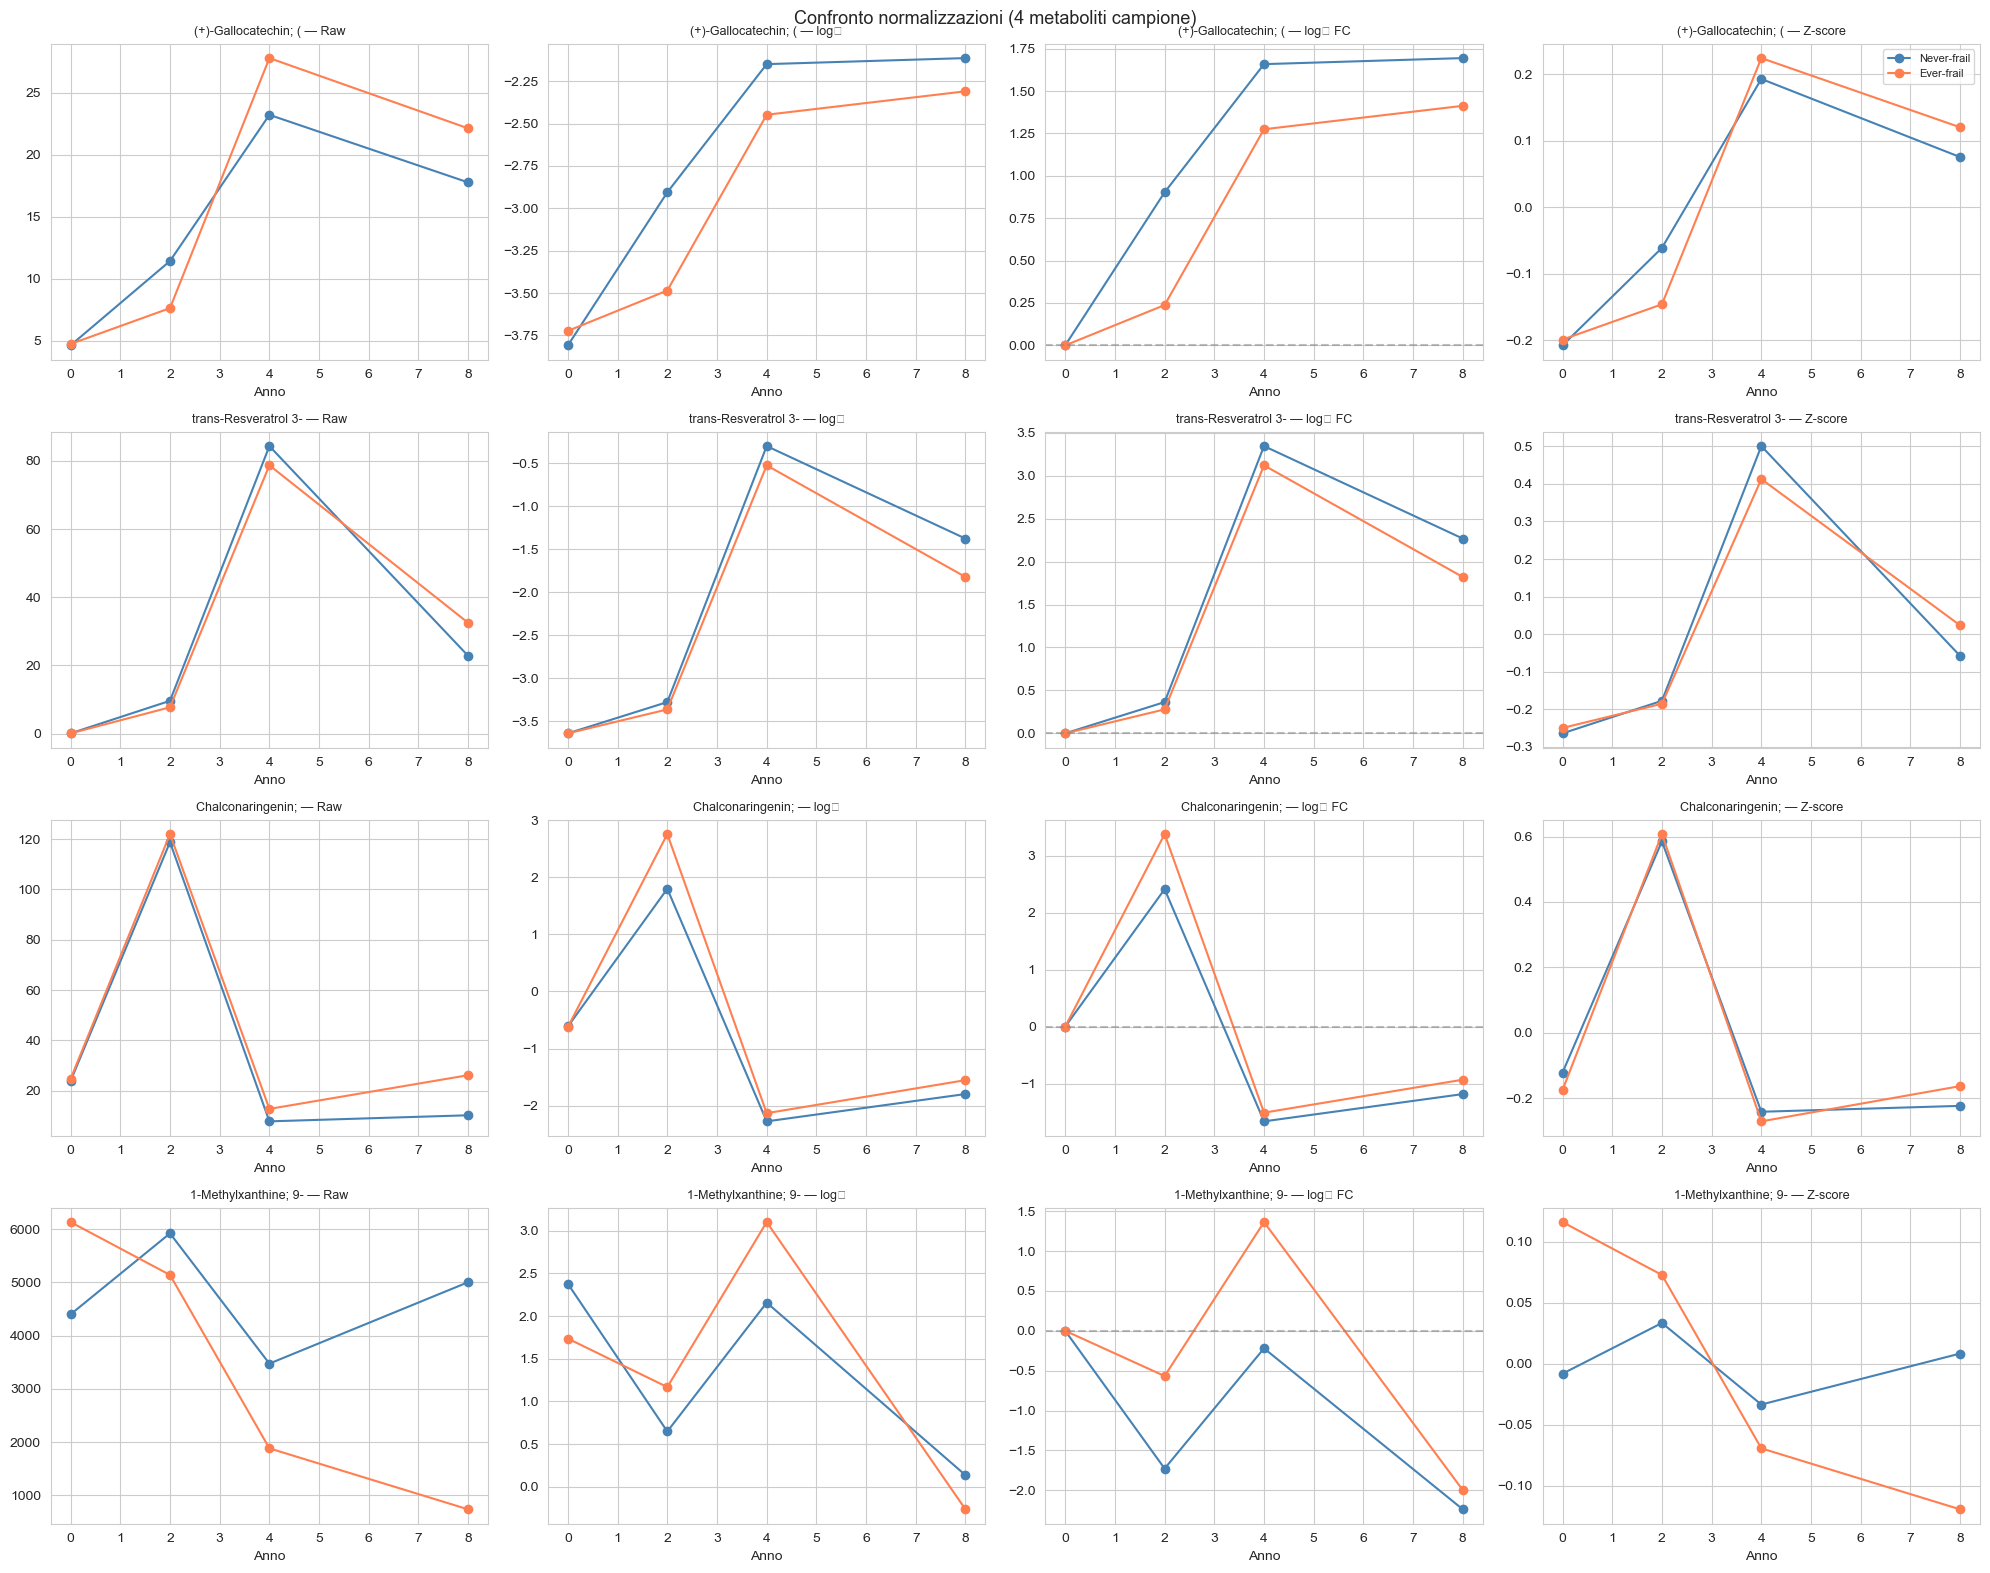

→ log₂ FC è il metodo usato in TCAM: interpretabile, rimuove soggetto-specificità


In [27]:
# ── CONFRONTO VISIVO SU 4 METABOLITI CAMPIONE ─────────────────────────
sample_mets = met_cols[:4]
n_sample = len(sample_mets)

# Calcola le normalizzazioni
X = df_master[["Code", "Time", "Years", "Group"] + met_cols].copy()
baseline = X[X["Time"] == 1].set_index("Code")[met_cols]

fig, axes = plt.subplots(n_sample, 4, figsize=(20, 4 * n_sample))
norm_labels = ["Raw", "log₂", "log₂ FC", "Z-score"]

for i, m in enumerate(sample_mets):
    # Raw
    for grp in ["Never-frail", "Ever-frail"]:
        sub = X[X["Group"] == grp]
        gm = sub.groupby("Years")[m].mean()
        axes[i, 0].plot(gm.index, gm.values, "o-", label=grp, color=colors[grp])
    axes[i, 0].set_title(f"{m[:20]} — Raw", fontsize=9)

    # log2
    for grp in ["Never-frail", "Ever-frail"]:
        sub = X[X["Group"] == grp].copy()
        sub[m + "_l2"] = np.log2(sub[m].clip(lower=1e-12))
        gm = sub.groupby("Years")[m + "_l2"].mean()
        axes[i, 1].plot(gm.index, gm.values, "o-", label=grp, color=colors[grp])
    axes[i, 1].set_title(f"{m[:20]} — log₂", fontsize=9)

    # log2 FC
    for grp in ["Never-frail", "Ever-frail"]:
        sub = X[X["Group"] == grp].copy()
        bl = sub[sub["Time"] == 1].set_index("Code")[m]
        sub["fc"] = sub.apply(lambda r: np.log2(r[m] / bl.get(r["Code"], np.nan)), axis=1)
        gm = sub.groupby("Years")["fc"].mean()
        axes[i, 2].plot(gm.index, gm.values, "o-", label=grp, color=colors[grp])
    axes[i, 2].axhline(0, ls="--", c="gray", alpha=0.5)
    axes[i, 2].set_title(f"{m[:20]} — log₂ FC", fontsize=9)

    # Z-score
    for grp in ["Never-frail", "Ever-frail"]:
        sub = X[X["Group"] == grp].copy()
        mu, sd = sub[m].mean(), sub[m].std()
        sub["z"] = (sub[m] - mu) / max(sd, 1e-12)
        gm = sub.groupby("Years")["z"].mean()
        axes[i, 3].plot(gm.index, gm.values, "o-", label=grp, color=colors[grp])
    axes[i, 3].set_title(f"{m[:20]} — Z-score", fontsize=9)

for ax in axes.ravel():
    ax.set_xlabel("Anno")
axes[0, -1].legend(fontsize=8)
plt.suptitle("Confronto normalizzazioni (4 metaboliti campione)", fontsize=13)
plt.tight_layout(); plt.show()

print("→ log₂ FC è il metodo usato in TCAM: interpretabile, rimuove soggetto-specificità")

## J. Metaboliti candidati — analisi univariata

Identificazione preliminare dei metaboliti associati a fragilità:
1. **Mann-Whitney U** (Ever-frail vs Never-frail, pooled across visits)
2. **Correlazione di Spearman** con FI
3. **Clustermap** della matrice di correlazione inter-metaboliti

> Questa analisi è **complementare** a TCAM, non sostitutiva.
> TCAM sfrutta la struttura tensoriale longitudinale.

Mann-Whitney U: 41/193 significativi (FDR < 0.05)

Top 15:


,metabolite,p,q,r_effect,mean_EF,mean_NF
0,129795,9.813270e-07,0.000189,-0.079437,13528.460855,7847.672921
1,126048,3.437457e-06,0.000285,0.110160,33.868980,50.139814
2,88195,4.992174e-06,0.000285,0.123177,1084.802237,1256.321444
3,Avenanthramide L,5.896813e-06,0.000285,-0.064037,331.805461,170.309508
4,133960,1.049248e-05,0.000405,0.119137,42397.550000,48769.340536
5,Chlorogenic acid,1.514143e-05,0.000487,-0.064781,128.506645,105.198271
6,Methylgallic acid-O-sulphate,2.091468e-05,0.000577,0.108779,210.893980,270.789562
7,Uric acid,3.279475e-05,0.000791,0.112281,20750.691875,23523.202177
8,Hydroxycotinine,5.469589e-05,0.001173,-0.102922,451.509967,261.514475
9,88933,8.128293e-05,0.001569,0.105031,611.698125,728.057298



Spearman con FI: 119/193 significativi (FDR < 0.05)

Top 15:


,metabolite,rho,p,q
0,Urolithin C 3-glucuronide,0.203855,2.895215e-24,5.587766e-22
1,Daidzein,-0.199739,2.429664e-23,2.344626e-21
2,130809,0.197684,6.908663e-23,4.444573e-21
3,myo-Inositol,0.194444,3.505911e-22,1.691602e-20
4,Ethyl glucuronide,0.183737,6.142766e-20,2.371108e-18
5,Campesteryl p-coumarate,-0.182734,9.812821e-20,3.156457e-18
6,Resveratrol-O-glucuronide,0.170656,2.236205e-17,6.165536e-16
7,"trans-Resveratrol 3,4'-disulfate",0.166524,1.311303e-16,3.163518e-15
8,Acesulfame; Acesulfame K;,-0.159203,2.700612e-15,5.791311e-14
9,Gallic acid,-0.153710,2.384965e-14,4.602983e-13


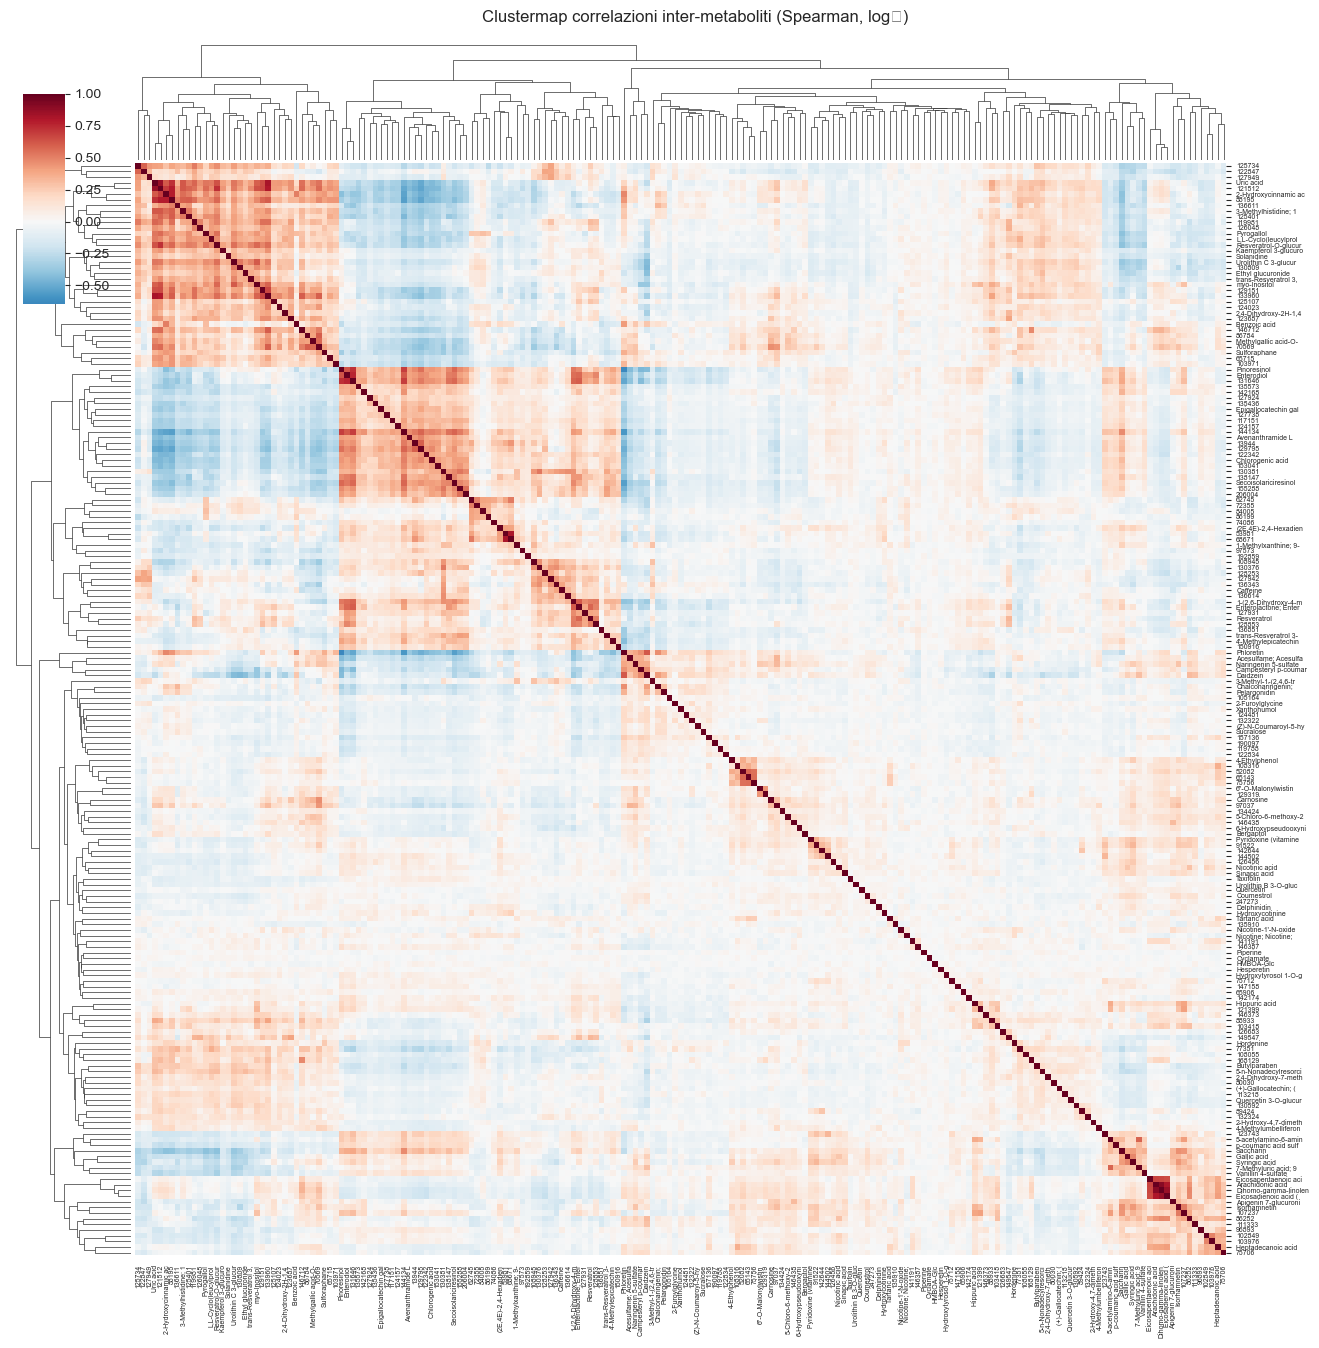

In [28]:
# ── MANN-WHITNEY U (Ever vs Never, pooled) ────────────────────────────
mw_results = []
ef_data = df_master[df_master["Group"] == "Ever-frail"]
nf_data = df_master[df_master["Group"] == "Never-frail"]

for m in met_cols:
    x = ef_data[m].dropna().values
    y = nf_data[m].dropna().values
    if len(x) > 5 and len(y) > 5:
        stat, p = mannwhitneyu(x, y, alternative="two-sided")
        # Effect size: rank-biserial r = 1 - 2U/(n1*n2)
        r_eff = 1 - (2 * stat) / (len(x) * len(y))
        mw_results.append({"metabolite": m, "U": stat, "p": p,
                            "r_effect": r_eff,
                            "mean_EF": x.mean(), "mean_NF": y.mean()})

mw_df = pd.DataFrame(mw_results).sort_values("p").reset_index(drop=True)
mw_df["q"] = fdr_bh(mw_df["p"].values)
n_sig_mw = (mw_df["q"] < 0.05).sum()
print(f"Mann-Whitney U: {n_sig_mw}/{len(mw_df)} significativi (FDR < 0.05)")
print("\nTop 15:")
display(mw_df.head(15)[["metabolite", "p", "q", "r_effect", "mean_EF", "mean_NF"]])

# ── SPEARMAN CORRELATION con FI ──────────────────────────────────────
spear_results = []
for m in met_cols:
    mask = df_master[m].notna() & df_master["FI"].notna()
    if mask.sum() > 10:
        rho, p = spearmanr(df_master.loc[mask, m], df_master.loc[mask, "FI"])
        spear_results.append({"metabolite": m, "rho": rho, "p": p})

spear_df = pd.DataFrame(spear_results).sort_values("p").reset_index(drop=True)
spear_df["q"] = fdr_bh(spear_df["p"].values)
n_sig_sp = (spear_df["q"] < 0.05).sum()
print(f"\nSpearman con FI: {n_sig_sp}/{len(spear_df)} significativi (FDR < 0.05)")
print("\nTop 15:")
display(spear_df.head(15)[["metabolite", "rho", "p", "q"]])

# ── CLUSTERMAP (correlazione inter-metaboliti, log2) ──────────────────
X_log2 = np.log2(df_master[met_cols].astype(float).clip(lower=1e-12))
corr = X_log2.corr(method="spearman")

# Abbrevia nomi per leggibilità
short_names = [m[:20] for m in met_cols]
corr.index = short_names; corr.columns = short_names

g = sns.clustermap(corr, cmap="RdBu_r", center=0, figsize=(14, 14),
                   xticklabels=True, yticklabels=True,
                   dendrogram_ratio=0.1, cbar_pos=(0.02, 0.8, 0.03, 0.15))
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=5, rotation=90)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=5)
plt.suptitle("Clustermap correlazioni inter-metaboliti (Spearman, log₂)", y=1.01)
plt.show()

## L. Floor effect per gruppo

Verifica se il floor è equidistribuito tra Ever-frail e Never-frail.
Un floor sbilanciato potrebbe confondere i risultati di TCAM / univariata.

Floor per gruppo — metaboliti con maggiore differenza:


,Ever-frail_%floor,Never-frail_%floor,diff
126048,68.9,58.7,10.2
Methylgallic acid-O-sulphate,54.8,44.8,10.0
88195,22.9,13.4,9.5
88933,37.2,28.1,9.1
Vanillin 4-sulfate,47.2,56.2,9.0
136343,55.3,46.9,8.3
129795,80.4,88.1,7.6
127949,80.4,73.0,7.5
Phloretin,33.1,25.7,7.4
121512,19.1,12.0,7.0


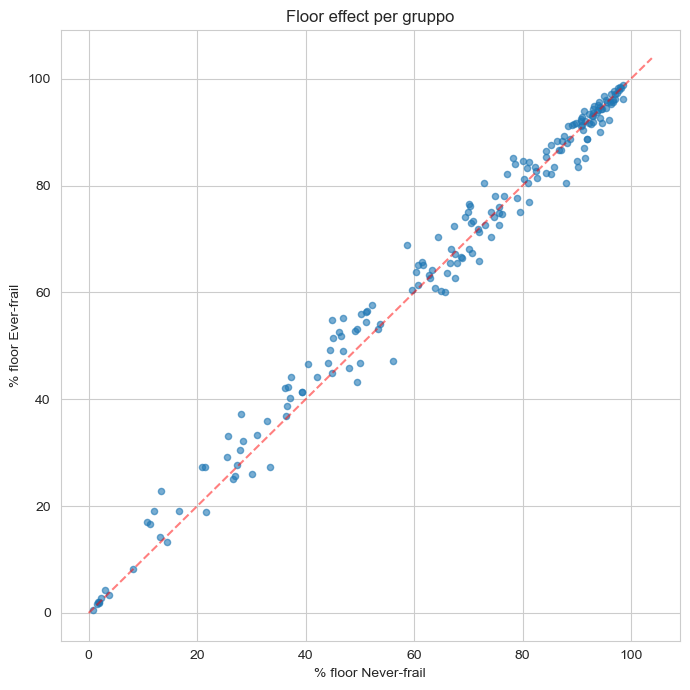


Metaboliti con differenza > 5pp nel floor tra gruppi: 39/193


In [30]:
# ── FLOOR PER GRUPPO ──────────────────────────────────────────────────
floors_g = df_master[met_cols].min(axis=0)
is_floor_g = df_master[met_cols].eq(floors_g, axis=1)

pct_ef = is_floor_g[df_master["Group"] == "Ever-frail"].mean(axis=0) * 100
pct_nf = is_floor_g[df_master["Group"] == "Never-frail"].mean(axis=0) * 100

floor_grp = pd.DataFrame({"Ever-frail_%floor": pct_ef, "Never-frail_%floor": pct_nf})
floor_grp["diff"] = (floor_grp["Ever-frail_%floor"] - floor_grp["Never-frail_%floor"]).abs()
floor_grp = floor_grp.sort_values("diff", ascending=False)

print("Floor per gruppo — metaboliti con maggiore differenza:")
display(floor_grp.head(10).round(1))

# Scatter: % floor EF vs NF
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(pct_nf, pct_ef, s=20, alpha=0.6)
lim = max(pct_nf.max(), pct_ef.max()) + 5
ax.plot([0, lim], [0, lim], "r--", alpha=0.5)
ax.set_xlabel("% floor Never-frail")
ax.set_ylabel("% floor Ever-frail")
ax.set_title("Floor effect per gruppo")
plt.tight_layout(); plt.show()

bias_count = (floor_grp["diff"] > 5).sum()
print(f"\nMetaboliti con differenza > 5pp nel floor tra gruppi: {bias_count}/{len(met_cols)}")

Analizzando 88 metaboliti con floor ≤ 70%
FLOOR PER TIMEPOINT E GRUPPO


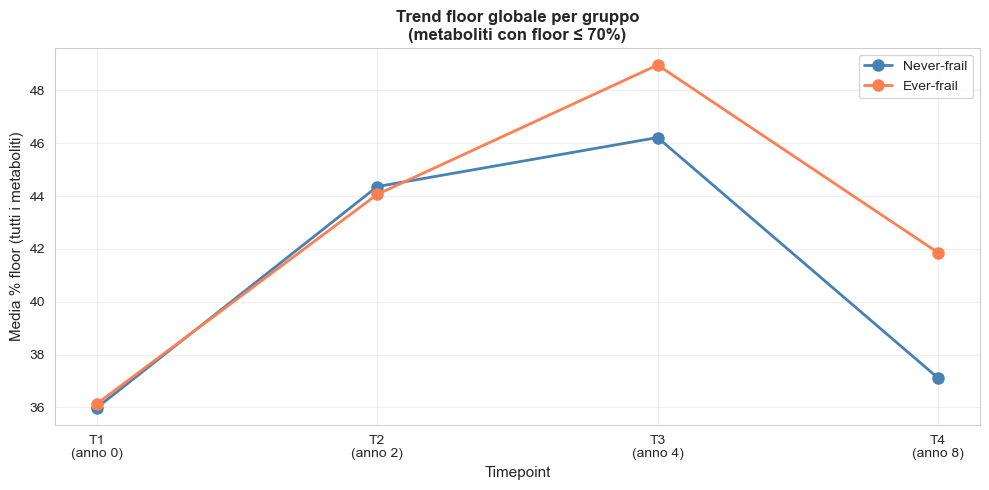


✓ Analisi completata
  Metaboliti analizzati: 88/193
  Soglia floor: 70%
  Timepoint: [1, 2, 3, 4]

Media % floor per gruppo e timepoint:


,Timepoint,Never-frail_%floor,Ever-frail_%floor,Differenza
0,T1 (anno 0),35.99,36.14,0.15
1,T2 (anno 2),44.36,44.06,0.29
2,T3 (anno 4),46.22,48.96,2.75
3,T4 (anno 8),37.12,41.86,4.74


In [61]:
# ── FLOOR PER TIMEPOINT E GRUPPO ──────────────────────────────────────

# ── PARAMETRI ─────────────────────────────────────────────────────────
FLOOR_THR_PLOT = 70  # Soglia floor: usa 100 per includere tutti i metaboliti
                      # Abbassa (es. 40, 50) per escludere metaboliti con alto floor

# ── SELEZIONE METABOLITI ──────────────────────────────────────────────
if FLOOR_THR_PLOT < 100:
    mets_plot = pct_floor[pct_floor <= FLOOR_THR_PLOT].index.tolist()
    print(f"Analizzando {len(mets_plot)} metaboliti con floor ≤ {FLOOR_THR_PLOT}%")
else:
    mets_plot = met_cols
    print(f"Analizzando tutti i {len(mets_plot)} metaboliti")

# ── CALCOLO FLOOR PER TIMEPOINT E GRUPPO ──────────────────────────────
print("=" * 70)
print("FLOOR PER TIMEPOINT E GRUPPO")
print("=" * 70)

# Verifica se Group esiste, altrimenti ricostruiscilo
if "Group" not in df_master.columns:
    print("\n⚠️  Colonna 'Group' non trovata, ricostruzione in corso...")
    ever_frail_map = (
        df_master.groupby("Code")["FI"].max() >= FRAIL_THR
    ).map({True: "Ever-frail", False: "Never-frail"})
    df_master["Group"] = df_master["Code"].map(ever_frail_map)
    df_master["Group"] = pd.Categorical(df_master["Group"],
                                         categories=["Never-frail", "Ever-frail"])
    print("✓ Colonna 'Group' ricostruita")

# Definisci colors se non esiste
if 'colors' not in locals():
    colors = {"Never-frail": "steelblue", "Ever-frail": "coral"}

# Calcola floor per subset selezionato
floors_t = df_master[mets_plot].min(axis=0)
is_floor_t = df_master[mets_plot].eq(floors_t, axis=1)

floor_by_time_group = {}
for t in TIMES:
    for grp in ["Never-frail", "Ever-frail"]:
        mask = (df_master["Time"] == t) & (df_master["Group"] == grp)
        pct = is_floor_t[mask].mean(axis=0) * 100
        floor_by_time_group[(t, grp)] = pct

# ── GRAFICO ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for grp in ["Never-frail", "Ever-frail"]:
    means = [floor_by_time_group[(t, grp)].mean() for t in TIMES]
    ax.plot(TIMES, means, "o-", label=grp, color=colors[grp], 
            linewidth=2, markersize=8)

ax.set_xlabel("Timepoint", fontsize=11)
ax.set_ylabel("Media % floor (tutti i metaboliti)", fontsize=11)
title = f"Trend floor globale per gruppo"
if FLOOR_THR_PLOT < 100:
    title += f"\n(metaboliti con floor ≤ {FLOOR_THR_PLOT}%)"
ax.set_title(title, fontsize=12, fontweight="bold")
ax.set_xticks(TIMES)
ax.set_xticklabels([f"T{t}\n(anno {TIME_TO_YEARS[t]})" for t in TIMES])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── STATISTICHE RIASSUNTIVE ───────────────────────────────────────────
print(f"\n✓ Analisi completata")
print(f"  Metaboliti analizzati: {len(mets_plot)}/{len(met_cols)}")
print(f"  Soglia floor: {FLOOR_THR_PLOT}%")
print(f"  Timepoint: {TIMES}")

# Tabella % floor medio per gruppo e timepoint
summary_table = pd.DataFrame({
    "Timepoint": [f"T{t} (anno {TIME_TO_YEARS[t]})" for t in TIMES],
    "Never-frail_%floor": [floor_by_time_group[(t, "Never-frail")].mean() for t in TIMES],
    "Ever-frail_%floor": [floor_by_time_group[(t, "Ever-frail")].mean() for t in TIMES]
})
summary_table["Differenza"] = (summary_table["Ever-frail_%floor"] - 
                                 summary_table["Never-frail_%floor"]).abs()

print("\nMedia % floor per gruppo e timepoint:")
display(summary_table.round(2))

Metaboliti analizzati (LMM): 39/193

TREND FLOOR NEL TEMPO (LMM: y ~ Years + (1|Code), Years=0/2/4/8)
Significativi (FDR<0.05): 33/39
  ↑ in aumento: 15
  ↓ in diminuzione: 18

Top 15 ↑:


,metabolite,beta_years,delta_per_2years,p,q,pct_floor_T1,pct_floor_T2,pct_floor_T3,pct_floor_T4
9,Daidzein,0.0988,0.1977,0.0000,0.0000,1.3136,6.4039,44.8276,75.0411
7,86252,0.0677,0.1354,0.0000,0.0000,11.9869,21.8391,48.4401,63.8752
22,Saccharin,0.0338,0.0675,0.0000,0.0000,10.6732,18.7192,15.4351,39.0805
27,Benzoic acid,0.0217,0.0433,0.0000,0.0000,2.6273,4.1051,30.0493,16.9130
2,Carnosine,0.0296,0.0591,0.0000,0.0000,11.1658,45.8128,58.9491,40.3941
24,88195,0.0225,0.0450,0.0000,0.0000,1.1494,4.2693,42.5287,15.1067
6,Dihomo-gamma-linolenic acid (DGLA; cis-20:3n-6),0.0275,0.0549,0.0000,0.0000,19.0476,36.6174,49.7537,42.8571
29,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,0.0181,0.0361,0.0000,0.0000,0.1642,2.1346,36.4532,10.8374
26,121512,0.0188,0.0375,0.0000,0.0000,0.0000,3.2841,40.7225,11.1658
15,Phloretin,0.0244,0.0489,0.0000,0.0000,8.2102,8.3744,73.3990,20.0328



Top 15 ↓:


,metabolite,beta_years,delta_per_2years,p,q,pct_floor_T1,pct_floor_T2,pct_floor_T3,pct_floor_T4
3,"1-(2,6-Dihydroxy-4-methoxyphenyl)-3-phenyl-1-p...",-0.0764,-0.1527,0.0,0.0,60.7553,61.0837,25.2874,5.4187
17,Pinoresinol,-0.0481,-0.0962,0.0,0.0,20.8539,77.3399,4.2693,4.1051
13,Secoisolariciresinol,-0.0431,-0.0863,0.0,0.0,39.0805,53.6946,10.0164,13.6289
19,131646,-0.0403,-0.0806,0.0,0.0,13.7931,79.6388,6.2397,5.2545
8,127931,-0.0363,-0.0726,0.0,0.0,48.2759,35.7964,33.1691,17.5698
23,128853,-0.0233,-0.0466,0.0,0.0,27.5862,18.7192,15.1067,7.8818
4,Resveratrol,-0.0290,-0.0580,0.0,0.0,49.5895,42.0361,33.6617,26.2726
0,Resveratrol-O-glucuronide,-0.0277,-0.0554,0.0,0.0,38.5878,46.9622,55.9934,17.8982
5,Caffeine,-0.0234,-0.0468,0.0,0.0,56.3218,27.4220,36.4532,30.7061
30,5-acetylamino-6-amino-3-methyluracil ((AAMU),-0.0106,-0.0213,0.0,0.0,11.9869,11.0016,5.5829,4.1051



File salvato: data/floor_trend_lmm_results.csv


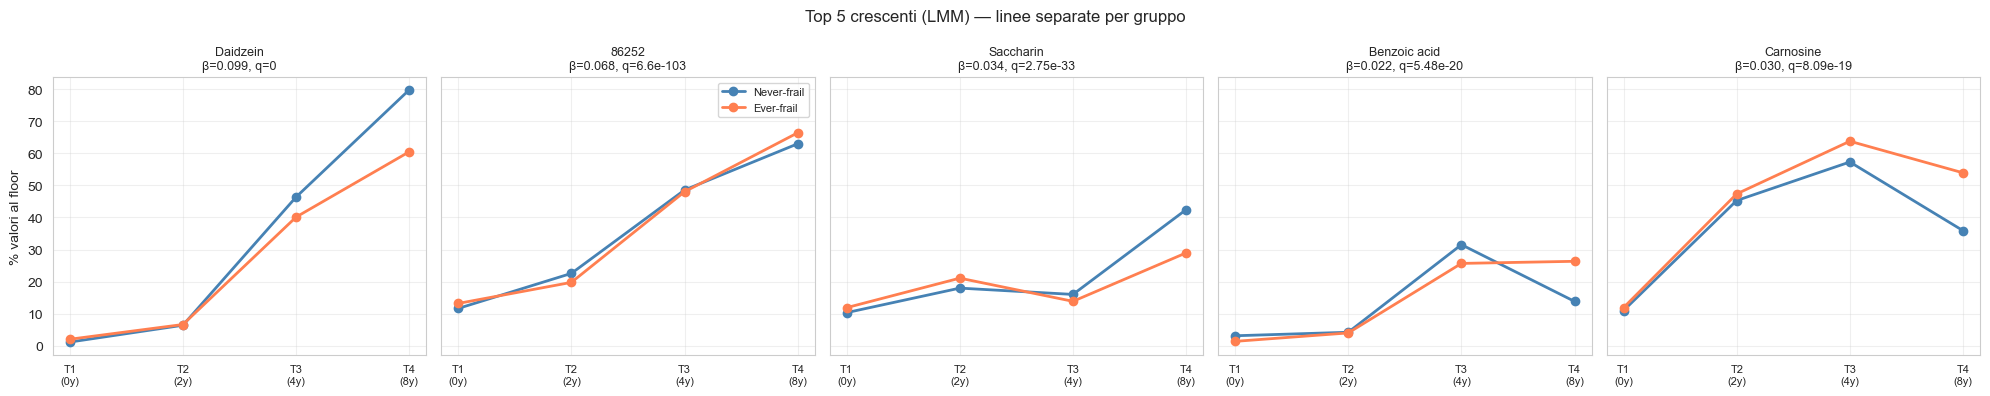

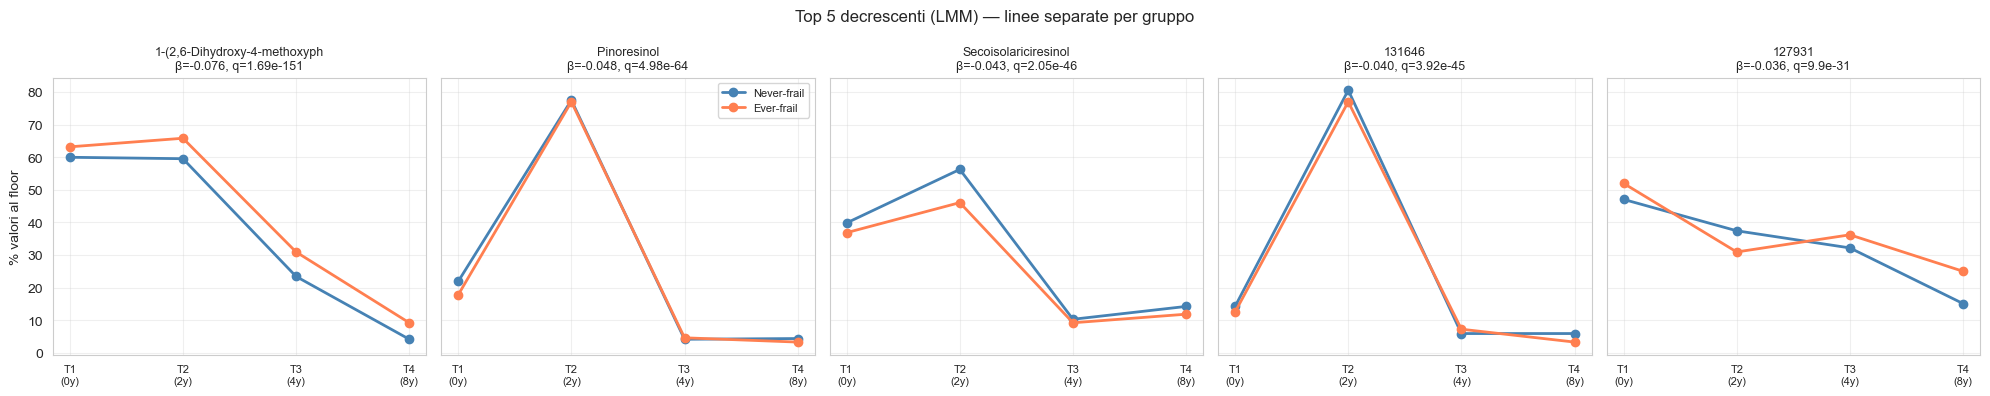

In [68]:
# ── L-TER. Trend floor nel tempo con LMM intra-soggetto (MixedLM) ──────
# y = 1 se valore al floor, 0 altrimenti
# modello: y ~ Years + (1 | Code)

import statsmodels.formula.api as smf

FLOOR_THR_LMM = 40  # 100 = tutti; es. 70/50/40

# Assicura Years (0,2,4,8)
if "Years" not in df_master.columns:
    df_master["Years"] = df_master["Time"].map(TIME_TO_YEARS)

# Selezione metaboliti
if FLOOR_THR_LMM < 100:
    mets_lmm = pct_floor[pct_floor <= FLOOR_THR_LMM].index.tolist()
else:
    mets_lmm = met_cols[:]

print(f"Metaboliti analizzati (LMM): {len(mets_lmm)}/{len(met_cols)}")

# Binario floor
floors_ref = df_master[mets_lmm].min(axis=0)
is_floor_bin = df_master[mets_lmm].eq(floors_ref, axis=1).astype(int)

rows = []
for m in mets_lmm:
    dat = pd.DataFrame({
        "y": is_floor_bin[m].astype(float),
        "Years": df_master["Years"].astype(float),
        "Time": df_master["Time"].astype(int),
        "Code": df_master["Code"]
    }).dropna()

    if dat["y"].nunique() < 2 or dat["Code"].nunique() < 2:
        beta, pval, direction = np.nan, np.nan, "flat"
    else:
        try:
            fit = smf.mixedlm("y ~ Years", data=dat, groups=dat["Code"]).fit(reml=False, method="lbfgs")
            beta = fit.params.get("Years", np.nan)
            pval = fit.pvalues.get("Years", np.nan)
            direction = "up" if (np.isfinite(beta) and beta > 0) else ("down" if (np.isfinite(beta) and beta < 0) else "flat")
        except Exception:
            beta, pval, direction = np.nan, np.nan, "flat"

    pct_t = (dat.groupby("Time")["y"].mean() * 100).reindex(TIMES)

    rows.append({
        "metabolite": m,
        "beta_years": beta,                # incremento assoluto di probabilità per anno (scala LMM)
        "delta_per_2years": beta * 2 if np.isfinite(beta) else np.nan,
        "p": pval,
        "direction": direction,
        "pct_floor_T1": pct_t.get(1, np.nan),
        "pct_floor_T2": pct_t.get(2, np.nan),
        "pct_floor_T3": pct_t.get(3, np.nan),
        "pct_floor_T4": pct_t.get(4, np.nan),
    })

lmm_df = pd.DataFrame(rows)
lmm_df["q"] = fdr_bh(lmm_df["p"].values)

sig = lmm_df[lmm_df["q"] < 0.05].copy()
sig_up = sig[sig["beta_years"] > 0].sort_values("q")
sig_down = sig[sig["beta_years"] < 0].sort_values("q")

print("\n" + "=" * 72)
print("TREND FLOOR NEL TEMPO (LMM: y ~ Years + (1|Code), Years=0/2/4/8)")
print("=" * 72)
print(f"Significativi (FDR<0.05): {len(sig)}/{len(lmm_df)}")
print(f"  ↑ in aumento: {len(sig_up)}")
print(f"  ↓ in diminuzione: {len(sig_down)}")

print("\nTop 15 ↑:")
display(sig_up.head(15)[[
    "metabolite", "beta_years", "delta_per_2years", "p", "q",
    "pct_floor_T1", "pct_floor_T2", "pct_floor_T3", "pct_floor_T4"
]].round(4))

print("\nTop 15 ↓:")
display(sig_down.head(15)[[
    "metabolite", "beta_years", "delta_per_2years", "p", "q",
    "pct_floor_T1", "pct_floor_T2", "pct_floor_T3", "pct_floor_T4"
]].round(4))

# Salvataggio risultati
lmm_df.sort_values("q").to_csv(f"{OUTDIR}/floor_trend_lmm_results.csv", index=False)
print(f"\nFile salvato: {OUTDIR}/floor_trend_lmm_results.csv")

# ...existing code...

# ── Grafici: top 5 crescenti / top 5 decrescenti con suddivisione per gruppo ──
# priorità ai significativi; se <5, completa con non-significativi più estremi
up_pool = lmm_df[lmm_df["beta_years"] > 0].sort_values(["q", "beta_years"], ascending=[True, False])
down_pool = lmm_df[lmm_df["beta_years"] < 0].sort_values(["q", "beta_years"], ascending=[True, True])

top_up = up_pool.head(5).copy()
top_down = down_pool.head(5).copy()

# Assicura colonna Group
if "Group" not in df_master.columns:
    ever_frail_map = (df_master.groupby("Code")["FI"].max() >= FRAIL_THR).map(
        {True: "Ever-frail", False: "Never-frail"}
    )
    df_master["Group"] = df_master["Code"].map(ever_frail_map)
    df_master["Group"] = pd.Categorical(df_master["Group"], categories=["Never-frail", "Ever-frail"])

if "colors" not in locals():
    colors = {"Never-frail": "steelblue", "Ever-frail": "coral"}

def plot_top_by_group(top_df, title):
    n = min(5, len(top_df))
    if n == 0:
        print(f"Nessun metabolita da plottare per: {title}")
        return

    fig, axes = plt.subplots(1, n, figsize=(4*n, 4), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, (_, r) in zip(axes, top_df.head(n).iterrows()):
        m = r["metabolite"]
        floor_m = df_master[m].min()
        tmp = df_master[["Time", "Group", m]].copy()
        tmp["is_floor"] = (tmp[m] == floor_m).astype(int)

        g = (tmp.groupby(["Time", "Group"])["is_floor"].mean() * 100).unstack("Group").reindex(TIMES)

        for grp in ["Never-frail", "Ever-frail"]:
            if grp in g.columns:
                ax.plot(TIMES, g[grp].values, marker="o", linewidth=2, color=colors[grp], label=grp)

        ax.set_title(f"{m[:28]}\nβ={r['beta_years']:.3f}, q={r['q']:.3g}", fontsize=9)
        ax.set_xticks(TIMES)
        ax.set_xticklabels([f"T{t}\n({TIME_TO_YEARS[t]}y)" for t in TIMES], fontsize=8)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel("% valori al floor")
    axes[min(1, n-1)].legend(fontsize=8, loc="best")
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

plot_top_by_group(top_up, "Top 5 crescenti (LMM) — linee separate per gruppo")
plot_top_by_group(top_down, "Top 5 decrescenti (LMM) — linee separate per gruppo")

